# **Beyond the Wind Tunnel: Machine Learning for F1 Front Wing Aerodynamics**


**Author:** *Christopher Won* 

**LinkedIn:** www.linkedin.com/in/christopher-won-a82046304

**Date completed:** 16/04/2026

# **Table of Contents**

* ## Introduction
* ## Data Exploration and Visualization
* ## PCA regression
* ## LASSO regression
* ## Ridge regression
* ## Random Forest regression
* ## Model Evaluation - Final Comparison
* ## Model Degradation Study
* ## Conclusion

# **_Introduction_**

The aim of this project is to apply supervised regression to predict two aerodynamically meaningful target variables: **aerodynamic efficiency** ($C_L/C_D$) and **aero balance** ($C_{LF}/C_L$), derived from Computational Fluid Dynamics (CFD) simulation data of a Formula 1 front wing. The dataset is sourced from a recent publication on Physics-Informed Neural Networks for F1 aerodynamics (Shah, 2025), and consists of 5,000 timestep samples with 12 input features covering pressure and viscous force and moment components in three spatial directions (X, Y, Z).

Each data point represents a single timestep of the CFD simulation, characterised by 12 raw force and moment measurements alongside known target values for aerodynamic efficiency ($C_L/C_D$) and aero balance ($C_{LF}/C_L$). The dataset is split 80/20 into training and test sets. A new point is a held-out timestep from the test set — one whose 12 force and moment readings were never seen during training. Four models are fitted to the training data and tasked with predicting the $C_L/C_D$ and $C_{LF}/C_L$ of these held-out timesteps, which are then compared against their known true values using **Mean Squared Error** (MSE).

The dataset used in this project was constructed by manually deriving the target variables ($C_L/C_D$) and ($C_{LF}/C_L$) from existing coefficient values provided in the publication, and combining with the feature columns in a new CSV file. It is worth acknowledging that if one has direct access to the individual aerodynamic coefficients (e.g. $C_L$ or $C_{LF}$), computing these target variables is straightforward arithmetic. However, this project operates under the assumption that such coefficients are **not** directly available — the goal is instead to predict aerodynamic efficiency and balance purely from raw force and moment simulation measurements, which is a more realistic scenario in practice.

It is also worth noting that the dataset provided by Shah (2025) includes a full column of 5,000 values for $C_{LR}$ (Rear Wing Lift Coefficient). We are assuming that this was simulated independently of the front wing  (values treated as fixed reference constants collected separately), and are taken as accurate within the simulation environment. This assumption is necessary to ensure the validity of the ($C_{LF}/C_L$) aero balance calculations used as ground truth throughout this project.

**Google Drive link to dataset:** https://drive.google.com/file/d/1tUvlr3CUOMsm9NeCi42GxJLydDEG3Q3y/view?usp=sharing

**Link to reference paper (Shah, 2025):** https://arxiv.org/abs/2509.01963

---

<div style="text-align: center;">
    
## **Limitations of the Simulation Environment**

</div>

It is important to note that the CFD simulation data used in this project 
does not fully replicate the aerodynamic conditions experienced by a Formula 1 car during 
an actual race. Several key simplifications are inherent to the simulation setup:

- **Straight-line flow only** — the simulation applies freestream airflow directly 
face-on to the front wing at a fixed velocity. In reality, a front wing operates under 
continuously varying conditions: yaw angles during cornering, pitch changes under 
braking and acceleration, and ride height variations over circuit undulations. None of 
these are captured in the present dataset.

- **Small dataset scale** — with 5,000 timesteps drawn from a single simulation run at 
a fixed flow condition, the dataset represents a single point in the car's design space. 
A real aerodynamic development programme would involve hundreds of CFD runs across 
varying speeds, ride heights, wing angles, and yaw conditions to build a representative 
surrogate model.

These simplifications mean that while the models trained here are valid and meaningful 
within the scope of this simulation environment, their predictions should not be 
interpreted as directly transferable to real on-track aerodynamic performance. The 
results are best understood as a proof of concept: demonstrating that supervised 
regression methods can accurately predict aerodynamic efficiency and balance from 
raw force and moment data, with the expectation that the same methodology would 
scale to a richer, multi-condition dataset in a full engineering context.

---

## **Proposed Pipeline**

The analysis is structured as follows:

1. **Data exploration and visualisation** — time series analysis, distribution inspection, 
and correlation analysis of the 12 input features and 2 target variables

2. **Dimensionality reduction** — Principal Component Analysis (PCA) on the 12 input 
features, retaining the top 3 components that explain around 90% of total variance, 
followed by PCA regression as a baseline predictive model

3. **Supervised regression** — comparison of three regularised regression methods trained 
directly on the 12 scaled input features:
   - LASSO Regression (L1 penalty — performs automatic feature selection)
   - Ridge Regression (L2 penalty — shrinks all coefficients without zeroing)
   - Random Forest Regression (non-linear ensemble method)

4. **Evaluation** — all models are evaluated on the held-out test set using MSE, 
with results compiled into a final comparison table

5. **Model degradation study** — training data is progressively subsampled to assess 
how much CFD data each method requires to maintain predictive accuracy

> **Note on residual analysis:** A formal residual analysis by simulation phase is 
> not conducted as a separate step. The transient phase boxplots in **1. Data exploration and visualisation** 
> already establish that CL/CD and CLF/CL exhibit extreme variance during the first 
> ~500 timesteps relative to steady-state. It is therefore self-evident that 
> prediction errors will be concentrated in the transient phase for all models;
> particularly linear methods will cannot capture the non-linear startup dynamics. 
> This is confirmed visually in the predicted vs actual plots for each model.

# **_Data Exploration and Visualization_**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot aesthetics
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style="whitegrid", palette="muted")

# Load dataset
df = pd.read_csv('f1project.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

# Important to note that CL/CD ratio has been transformed by |CL/CD|

Shape: (5000, 14)

Columns: ['PRESSURE_MOMENT_X', 'PRESSURE_MOMENT_Y', 'PRESSURE_MOMENT_Z', 'VISCOUS_MOMENT_X', 'VISCOUS_MOMENT_Y', 'VISCOUS_MOMENT_Z', 'PRESSURE_FORCE_X', 'PRESSURE_FORCE_Y', 'PRESSURE_FORCE_Z', 'VISCOUS_FORCE_X', 'VISCOUS_FORCE_Y', 'VISCOUS_FORCE_Z', 'CL/CD', 'CLF/CL']

First 5 rows:


,PRESSURE_MOMENT_X,PRESSURE_MOMENT_Y,PRESSURE_MOMENT_Z,VISCOUS_MOMENT_X,VISCOUS_MOMENT_Y,VISCOUS_MOMENT_Z,PRESSURE_FORCE_X,PRESSURE_FORCE_Y,PRESSURE_FORCE_Z,VISCOUS_FORCE_X,VISCOUS_FORCE_Y,VISCOUS_FORCE_Z,CL/CD,CLF/CL
0,-59.2,27.10,38.10,0.0343,0.700,0.04660,-65.10,-145.0,2.14,-1.69,0.0725,-0.00239,2.171315,0.022477
1,-102.0,38.50,59.50,0.0809,0.699,0.00632,-91.70,-251.0,4.26,-1.69,0.1850,-0.00564,2.688478,0.068783
2,-90.3,24.90,44.50,0.0901,0.679,-0.00613,-58.30,-224.0,3.92,-1.65,0.2080,-0.00826,3.725055,0.138095
3,-54.9,5.92,17.90,0.0936,0.662,-0.01270,-11.70,-136.0,2.27,-1.61,0.2150,-0.00967,10.200000,0.260784
4,-38.1,2.06,8.59,0.0921,0.654,-0.01270,-1.65,-92.9,1.69,-1.60,0.2090,-0.00906,28.606557,0.330946


In [2]:
# Data types and null check
print("=== Data Types & Missing Values ===")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# Summary statistics
print("\n=== Descriptive Statistics ===")
df.describe().T

=== Data Types & Missing Values ===
PRESSURE_MOMENT_X    float64
PRESSURE_MOMENT_Y    float64
PRESSURE_MOMENT_Z    float64
VISCOUS_MOMENT_X     float64
VISCOUS_MOMENT_Y     float64
VISCOUS_MOMENT_Z     float64
PRESSURE_FORCE_X     float64
PRESSURE_FORCE_Y     float64
PRESSURE_FORCE_Z     float64
VISCOUS_FORCE_X      float64
VISCOUS_FORCE_Y      float64
VISCOUS_FORCE_Z      float64
CL/CD                float64
CLF/CL               float64
dtype: object

Missing values per column:
PRESSURE_MOMENT_X    0
PRESSURE_MOMENT_Y    0
PRESSURE_MOMENT_Z    0
VISCOUS_MOMENT_X     0
VISCOUS_MOMENT_Y     0
VISCOUS_MOMENT_Z     0
PRESSURE_FORCE_X     0
PRESSURE_FORCE_Y     0
PRESSURE_FORCE_Z     0
VISCOUS_FORCE_X      0
VISCOUS_FORCE_Y      0
VISCOUS_FORCE_Z      0
CL/CD                0
CLF/CL               0
dtype: int64

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
PRESSURE_MOMENT_X,5000.0,-77.688500,2.503086,-102.000000,-77.500000,-77.300000,-77.100000,-38.100000
PRESSURE_MOMENT_Y,5000.0,19.192376,0.785854,2.060000,19.000000,19.100000,19.200000,38.500000
PRESSURE_MOMENT_Z,5000.0,23.054158,1.236892,8.590000,22.800000,22.900000,22.900000,59.500000
VISCOUS_MOMENT_X,5000.0,0.125489,0.005557,0.034300,0.126000,0.127000,0.127000,0.129000
VISCOUS_MOMENT_Y,5000.0,0.734747,0.012630,0.632000,0.737000,0.738000,0.739000,0.742000
VISCOUS_MOMENT_Z,5000.0,-0.067658,0.005202,-0.069800,-0.068900,-0.068700,-0.068300,0.046600
PRESSURE_FORCE_X,5000.0,-41.578270,1.914490,-91.700000,-41.400000,-41.300000,-41.200000,-1.650000
PRESSURE_FORCE_Y,5000.0,-209.847180,6.081967,-258.000000,-210.000000,-209.000000,-208.000000,-92.900000
PRESSURE_FORCE_Z,5000.0,5.706680,0.403017,1.690000,5.520000,5.720000,5.910000,8.450000
VISCOUS_FORCE_X,5000.0,-1.933636,0.039297,-1.950000,-1.940000,-1.940000,-1.940000,-1.560000


<div style="text-align: center;">
    
## **Feature Variable Descriptions**

The dataset contains **12 input features** derived from CFD simulation of an F1 front wing, 
split into two physical categories: **pressure** (force) and **viscous** (friction) contributions, 
each measured across three spatial directions (X, Y, Z).

### **Coordinate System**
**X** — streamwise direction (forward/backward along car),
**Y** — vertical direction (up/down, governs downforce),
**Z** — lateral/spanwise direction (left/right across wing width)

---

### **Pressure Features**
*(Dominant forces — driven by pressure differential across the wing surfaces)*

| Feature | Description |
|---|---|
| `PRESSURE_MOMENT_X` | Rolling moment due to pressure — rotation tendency about the streamwise axis |
| `PRESSURE_MOMENT_Y` | Yawing moment due to pressure — rotation tendency about the vertical axis |
| `PRESSURE_MOMENT_Z` | Pitching moment due to pressure — directly related to aero balance (CLF/CL) |
| `PRESSURE_FORCE_X` | Pressure drag — opposes forward motion, negative by convention |
| `PRESSURE_FORCE_Y` | Downforce — the dominant aerodynamic load (~−210 N (Newtons)), negative = downward |
| `PRESSURE_FORCE_Z` | Lateral pressure force — small mean (~5.7 N) with persistent spanwise oscillation |

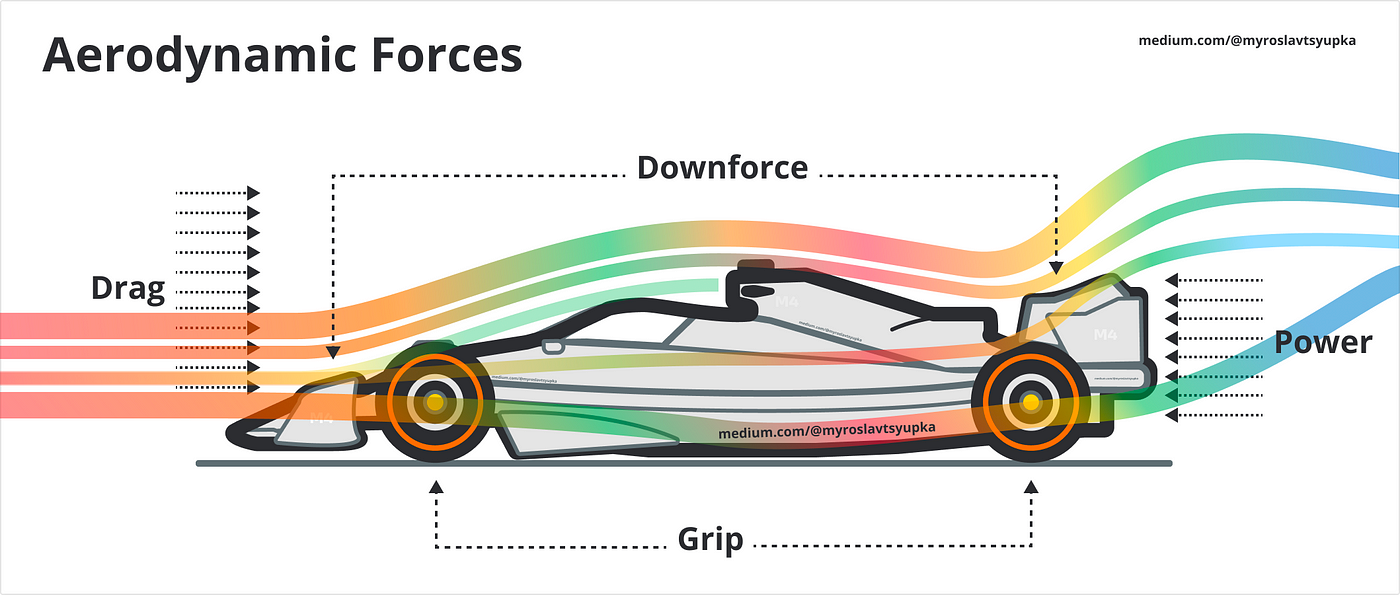

---

### **Viscous Features**
*(Secondary forces — driven by skin friction along the wing surface)*

| Feature | Description |
|---|---|
| `VISCOUS_MOMENT_X` | Rolling moment due to skin friction — very small magnitude |
| `VISCOUS_MOMENT_Y` | Yawing moment due to skin friction — very small magnitude |
| `VISCOUS_MOMENT_Z` | Pitching moment due to skin friction — negligible (~−0.068 N·m (Newton-meter)) |
| `VISCOUS_FORCE_X` | Viscous drag component — small relative to pressure drag |
| `VISCOUS_FORCE_Y` | Viscous contribution to vertical force — ~0.25 N vs ~−210 N pressure downforce |
| `VISCOUS_FORCE_Z` | Lateral viscous force — essentially numerical noise (~−0.004 N) |

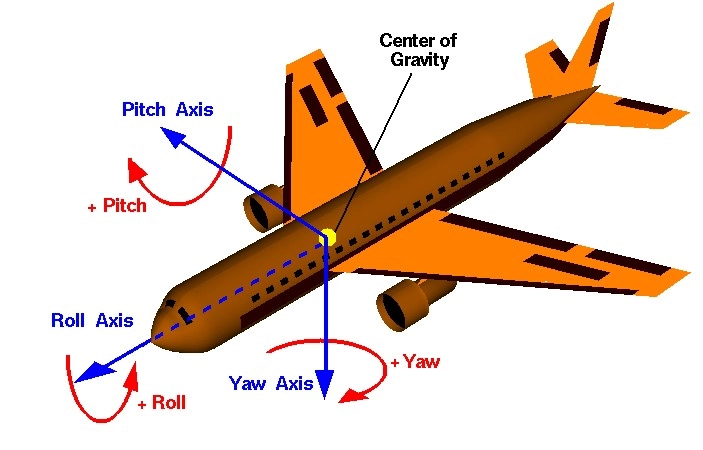
---

</div>

### **Target Variables**

| Variable | Description |
|---|---|
| `CL/CD` | **Aerodynamic efficiency** — ratio of lift (downforce) to drag |
| `CLF/CL` | **Aerodynamic balance** — fraction of total downforce generated by the front wing |

#### **Brief Explanation of Target variables**

##### **$C_L/C_D$ — Aerodynamic Efficiency**

In aerodynamics, forces acting on a body moving through air are decomposed into two 
components:

- **Lift ($C_L$)** — the force acting **perpendicular** to the flow direction. On an 
F1 car, the wings are inverted compared to an aircraft, so lift acts **downward** and this is what engineers call **downforce**. Downforce pushes the car into the track, increasing grip and allowing higher cornering speeds.

- **Drag ($C_D$)** — the force acting **parallel** to the flow direction, opposing 
the car's forward motion. Drag costs speed on the straights and increases fuel 
consumption.

These forces are expressed as dimensionless **coefficients** by normalising against 
dynamic pressure and a reference area:

$$C_L = \frac{F_L}{\frac{1}{2} \rho V^2 A}, \qquad C_D = \frac{F_D}{\frac{1}{2} \rho V^2 A}$$

where $\rho$ is air density, $V$ is freestream velocity, $A$ is the reference 
area of the wing, and $F_{L}$ or $F_{D}$ is the the sum of forces in the specified lift direction. Using coefficients rather than raw forces makes the values 
independent of speed and size, allowing fair comparison across configurations.

**Aerodynamic efficiency** is simply the ratio of these two coefficients:

$$\frac{C_L}{C_D} = \frac{\text{Downforce}}{\text{Drag}}$$

A higher $C_L/C_D$ means the wing generates more downforce for a given amount of 
drag; it is a more efficient aerodynamic surface. In this dataset, the steady-state 
mean is approximately **4.82**, meaning the front wing produces ~4.82 units of 
downforce for every unit of drag it generates.


##### **$C_{LF}/C_L$ — Aerodynamic Balance**

A Formula 1 car generates downforce from multiple surfaces, primarily the front wing, 
rear wing, and the underfloor. **Aerodynamic balance** describes how this total 
downforce is distributed between the front and rear of the car:

$$\frac{C_{LF}}{C_L} = \frac{\text{Front wing downforce}}{\text{Total car downforce}}$$

where $C_{LF}$ is the lift coefficient of the front wing alone, and $C_L$ is the 
total lift coefficient of the entire car. A value of **0.30** means the front wing 
contributes **30% of the car's total downforce**, with the remaining 70% generated 
by the rear wing and underfloor.

Balance is critical to car handling. Too much downforce at the front relative to 
the rear causes **oversteer** (the rear slides out in corners), while too little 
front downforce causes **understeer** (the car ploughs straight on). F1 engineers 
adjust front wing angle between sessions specifically to tune this balance for each 
circuit's characteristics. For example, high-downforce circuits like Monaco demand a different balance to low-downforce circuits like Monza.

> Important to note that we have taken the absolute value of the CL/CD ratio for better readability.

<div style="text-align: center;">

## **Time-series plots: CFD Simulation Analysis of F1 Front Wing**

</div>

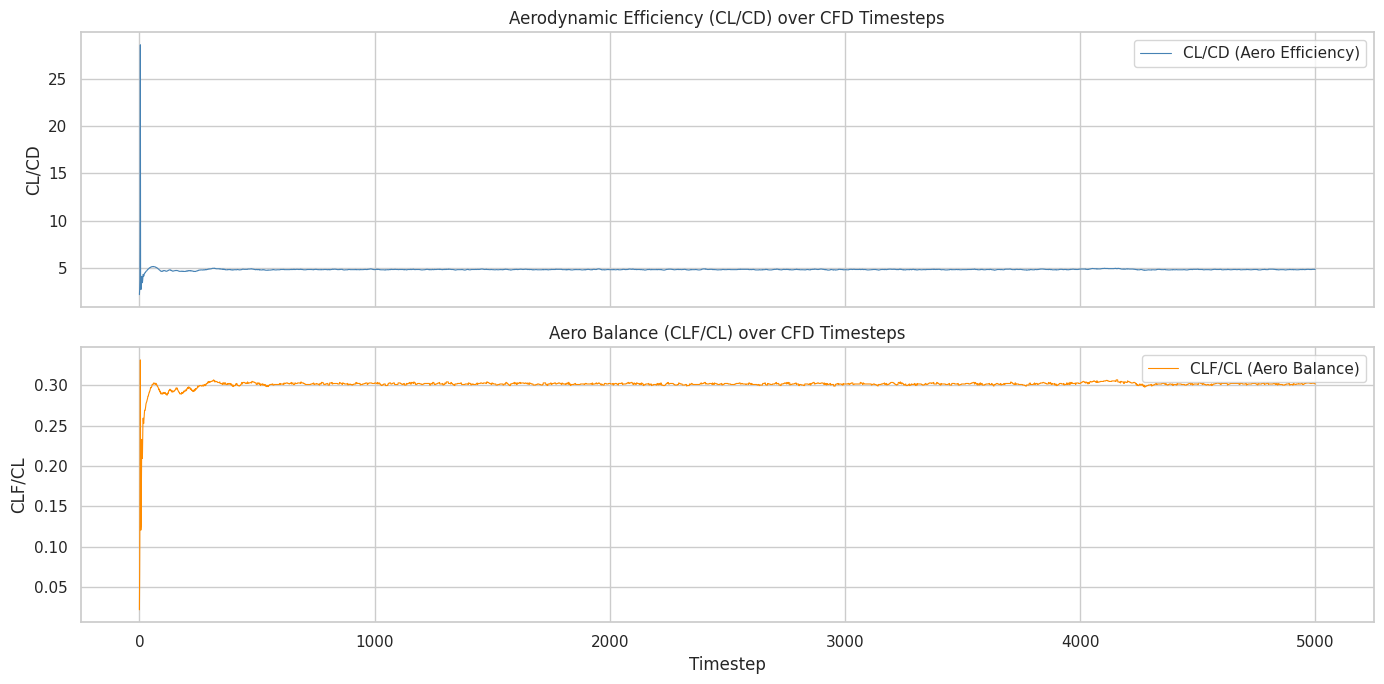

In [ ]:
#Target variables over simulation time 
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df.index, df['CL/CD'], color='steelblue', lw=0.8, label='CL/CD (Aero Efficiency)')
axes[0].set_ylabel('CL/CD')
axes[0].set_title('Aerodynamic Efficiency (CL/CD) over CFD Timesteps')
axes[0].legend()

axes[1].plot(df.index, df['CLF/CL'], color='darkorange', lw=0.8, label='CLF/CL (Aero Balance)')
axes[1].set_ylabel('CLF/CL')
axes[1].set_xlabel('Timestep')
axes[1].set_title('Aero Balance (CLF/CL) over CFD Timesteps')
axes[1].legend()

plt.tight_layout()
plt.savefig('timeseries_targets.png', dpi=150)
plt.show()

<div style="text-align: center;">

### 1. **Numerical Stability & Convergence**
The simulation reaches a **steady state** by approximately **1,000 timesteps**. The lack of oscillation in the latter 4,000 steps indicates a mathematically reliable solution.

### 2. **Aerodynamic Efficiency ($C_L/C_D$)**
**Result:** Settles at **~5.0**

* **Analysis:** For every **1 N of Drag** (pulling the car back) created, the wing produces **5 N of Downforce** (pushing the car down). 
* **Verdict:** This is a highly efficient profile for a front wing, compared to the results from paper below.



### 3. **Aero Balance ($C_{LF}/C_L$)**
**Result:** Settles at **0.30 (30%)**

* **Analysis:** At **30%**, the car is 'rear-loaded' majority of the downforce is at the rear (around 70%).
* **Verdict:** This setup would likely result in *understeer* (vehicle enters a curve with less force than the driver intended with the steering movement). To avoid this, it would be advisable to increase the wing's angle of attack. A study showed that the best aerodynamic efficiency ratio occured at 11 degrees producing ~ 225 N of downforce
[https://www.researchgate.net/publication/382250437_What_is_the_most_optimal_angle_of_attack_of_a_Formula_1_car's_front_wings_to_provide_the_most_aerodynamic_efficiency]

**Important:** The simulation environment is a static virtual wind tunnel. All forces are calculated based on head-on airflow, meaning the lateral (Z) components represent internal flow fluctuations rather than vehicle cornering forces.

---

### Performance Summary Table

| Metric | Value | Status |
| :--- | :---: | :--- |
| **Convergence Step** | ~1,000 | **Stable** |
| **Efficiency ($L/D$)** | 5.0 | **High** |
| **Aero Balance** | 30% | **Understeer Bias** |

</div>

<div style="text-align: center;">

## **Force Decomposition Analysis - Pressure Force Components (X, Y, Z)**

</div>

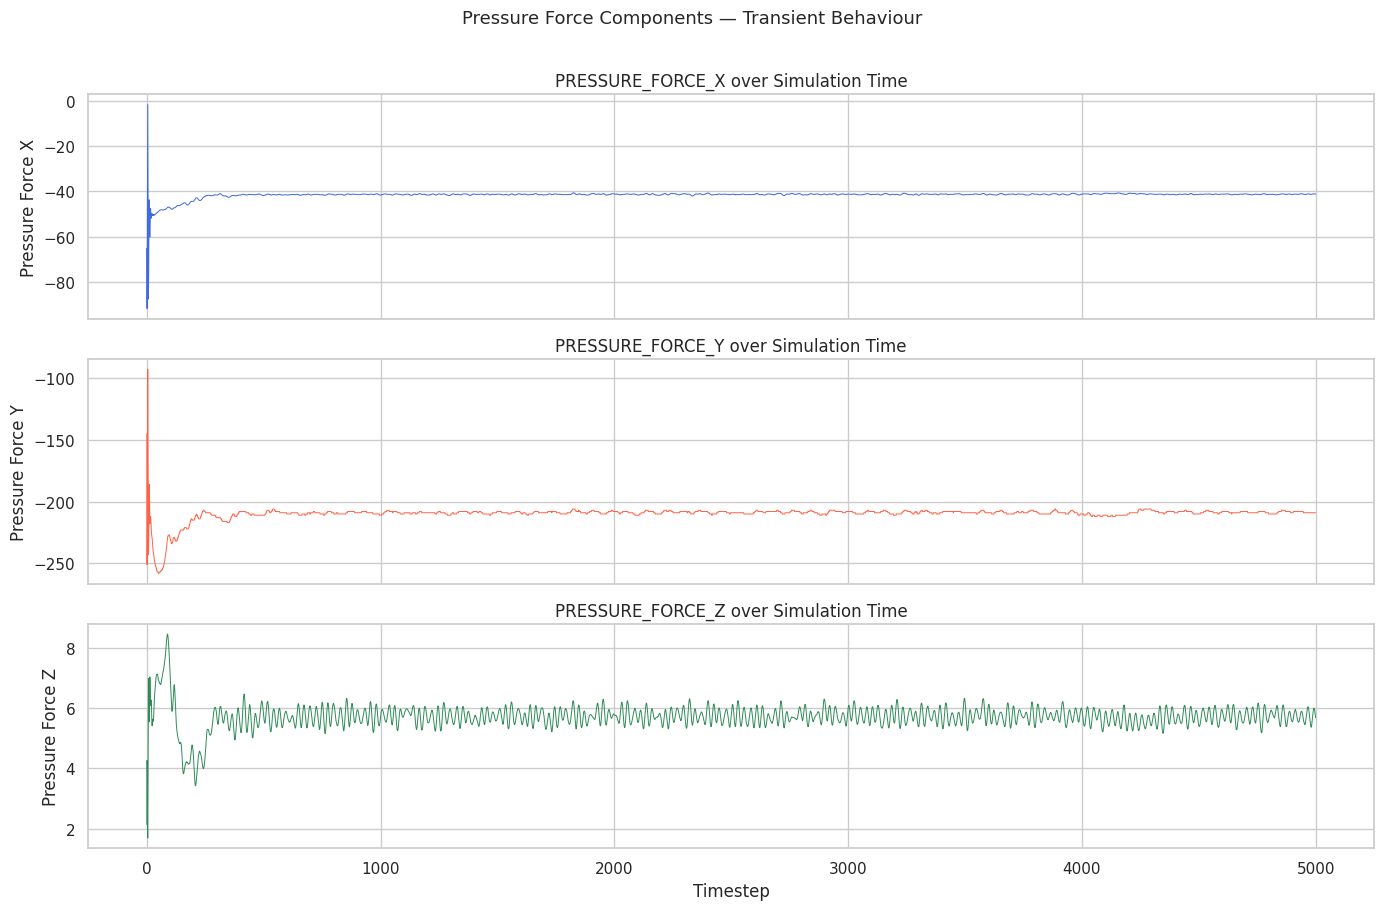

In [4]:
# Pressure forces over time (transient vs steady-state)
pressure_forces = ['PRESSURE_FORCE_X', 'PRESSURE_FORCE_Y', 'PRESSURE_FORCE_Z']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = ['royalblue', 'tomato', 'seagreen']
for ax, col, c in zip(axes, pressure_forces, colors):
    ax.plot(df.index, df[col], color=c, lw=0.7)
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.set_title(f'{col} over Simulation Time')
    
axes[-1].set_xlabel('Timestep')
plt.suptitle('Pressure Force Components — Transient Behaviour', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

<div style="text-align: center;">

### 1.**Longitudinal Drag ($F_x$) & Vertical Downforce ($F_y$)**
* **Observations:** Both $F_x$ (Blue) and $F_y$ (Red) show rapid convergence.
* **Physics:** $F_y$ settles at **~210 N** (Downforce), while $F_x$ settles at **~40 N** (Drag). These are the dominant forces acting on the wing, providing the steady grip needed for high-speed cornering.

### 2. **Lateral Force ($F_z$)**
* **Observation:** While the green line looks more chaotic, the y-axis is highly zoomed in with a range of only 4–6 N.
* **Physics - Spanwise Flow:** The persistent oscillation in $F_z$ is caused by **vortex shedding** (when fluid flows over a solid, creating an oscillating flow) and air moving sideways across the wing (spanwise flow). Because the force is so small (~5.7 N), these tiny air fluctuations appear exaggerated. 


### 3. **Key Takeaway**
The simulation is highly stable. The variance in the Lateral Force ($F_z$) is a result of axis scaling rather than simulation instability. In a racing context, this indicates the wing is generating consistent downforce with minimal side-to-side variability.

---

### **Summary of Mean Forces**

| Component | Direction | Mean Value | Behavior |
| :--- | :--- | :---: | :--- |
| **Pressure $F_x$** | Drag | ~40 N | Highly Stable |
| **Pressure $F_y$** | Downforce | ~210 N | Highly Stable |
| **Pressure $F_z$** | Lateral | ~5.7 N | Oscillatory (Small Scale) |

</div>

<div style="text-align: center;">

## **Force Decomposition Analysis - Viscous Force Components (X, Y, Z)**

</div>

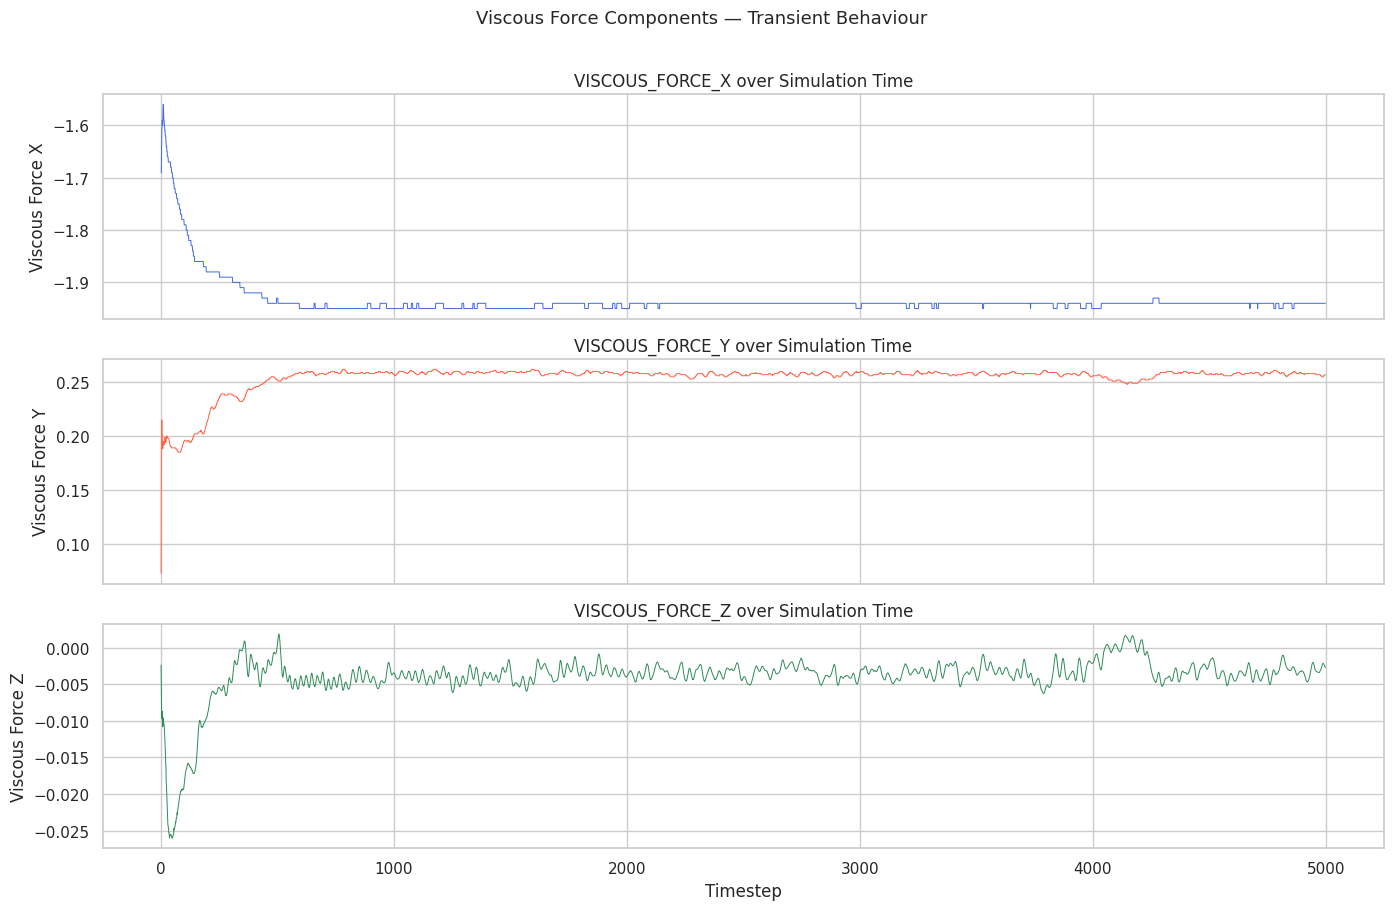

In [5]:
# Viscous forces over time (transient vs steady-state)
viscous_forces = ['VISCOUS_FORCE_X', 'VISCOUS_FORCE_Y', 'VISCOUS_FORCE_Z']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = ['royalblue', 'tomato', 'seagreen']
for ax, col, c in zip(axes, viscous_forces, colors):
    ax.plot(df.index, df[col], color=c, lw=0.7)
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.set_title(f'{col} over Simulation Time')
axes[-1].set_xlabel('Timestep')
plt.suptitle('Viscous Force Components — Transient Behaviour', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

<div style="text-align: center;">

## **Secondary Effects (Skin Friction)**

---

### 1. **The Nature of Viscous Forces**
**Viscous Forces** are caused by the 'stickiness' of the air rubbing against the wing's surface. 
* **Drag ($F_x$):** Settles at **~ -1.94 N**. This is the friction penalty of moving through air.
* **Downforce ($F_y$):** Settles at **~ 0.25 N**. Note that this is positive (upward), meaning skin friction actually works *slightly* against downforce, though the effect is marginal.

### 2. **The Lateral "Noise" ($F_z$)**
* **Observation:** Viscous force in the Z-direction is near zero.
* **Physics:** This is the force of air trying to 'drag' the wing sideways via friction. Because the wing is symmetric and the air flows primarily front-to-back, this value is essentially **negligible noise (~ -0.004 N)**.
* **Insight:** This feature ($F_z$) is highly likely a prime candidate for exclusion in **LASSO regression**, as it provides no meaningful predictive power for the car's performance.


### 3. **Comparison: Pressure vs. Viscous**
To put these graphs into perspective, compare the scales of the dominant vertical forces:

| Force Type | Direction | Magnitude | Impact |
| :--- | :--- | :---: | :--- |
| **Pressure $F_y$** | Downward | ~210.00 N | **Primary Grip** |
| **Viscous $F_y$** | Upward | ~0.25 N | **Negligible Friction** |

---

### **Summary**
The Viscous forces are orders of magnitude smaller than the Pressure forces. The simulation correctly shows that the F1 wing is a **pressure-driven** component, where skin friction plays only a minor role in overall drag and almost no role in lateral stability. We may expect to see that most if not all viscous feature variables are excluded in Lasso regression.

</div>

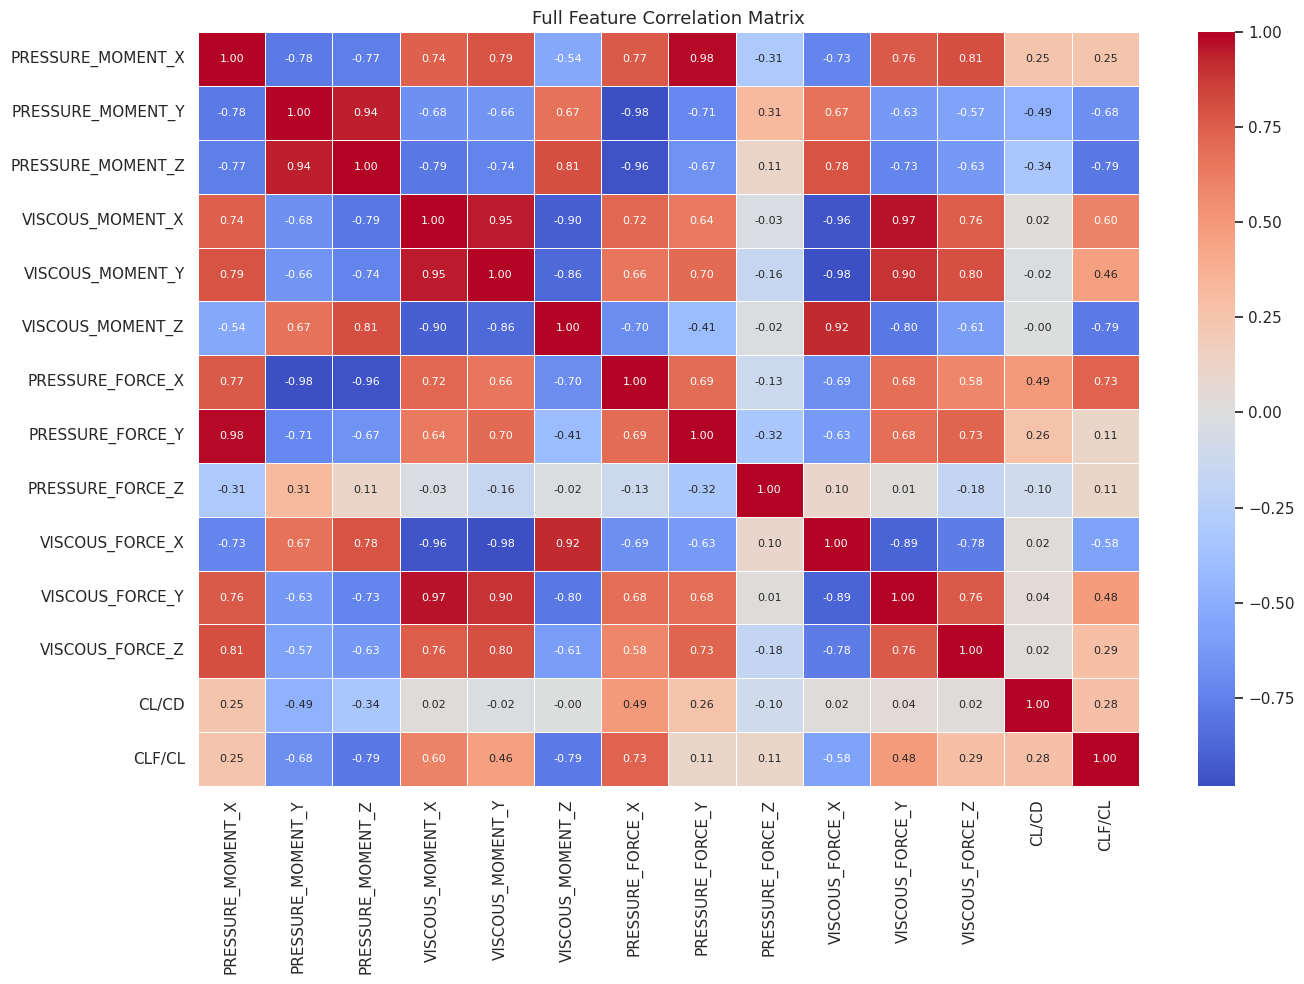

In [ ]:
# Full correlation heatmap --
# Calculate the correlation matrix
corr = df.corr()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(14, 10))

# Generate the full heatmap by removing the 'mask' argument
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5, 
            ax=ax,
            annot_kws={'size': 8})

ax.set_title('Full Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('full_correlation_heatmap.png', dpi=150)

<div style="text-align: center;">

## **Correlation Analysis: Target Variables**

---

### 1. **The Goal: Maximizing CL/CD (Efficiency)**
* **Correlation Check:** Looking at the bottom row of the correlation matrix, `CL/CD` shows a moderate positive correlation (**0.49**) with `PRESSURE_FORCE_X`. 
* **The Logic:** Since `CL/CD` is a ratio of Lift to Drag, the model will primarily look for the ideal spot where downforce is maximized without a massive penalty in drag.
* **Physics:** A higher efficiency means the car is light through the air but heavy in the corners.



### 2. **The Goal: Optimizing CLF/CL (Aero Balance)**
* **Correlation Check:** `CLF/CL` has a very strong negative correlation with `PRESSURE_MOMENT_Z` (**-0.79**) and `VISCOUS_MOMENT_Z` (**-0.79**).
* **The Logic:** The pitching moments ($M_z$), aerodynamic torque acting on the vehicle about its center of gravity, is the physical manifestation of Aero Balance. If the balance shifts forward, the pitching moment changes. 
* **Physics:** This variable tells us where the pressure is centralized. If it’s too far back (30%), the car won't turn well; if it’s too far forward, the rear will be unstable.

---

### **LASSO Modeling Strategy**

| Target | Key Predictive Features | Expected Outcome |
| :--- | :--- | :--- |
| **CL/CD** | Pressure X, Pressure Y | High accuracy; focuses on the force trade-off. |
| **CLF/CL** | Moment Z, Moment X | High accuracy; focuses on the rotational aspect and balance. |

### **Predictive Insight**
Because the targets (`CL/CD` and `CLF/CL`) are **ratios**, they are inherently non-linear. LASSO will help identify which *individual* forces contribute most to these ratios, allowing to build a simplified model that predicts complex aerodynamic behavior using only 2 or 3 sensor inputs.

</div>

phase
steady-state    4500
transient        500
Name: count, dtype: int64


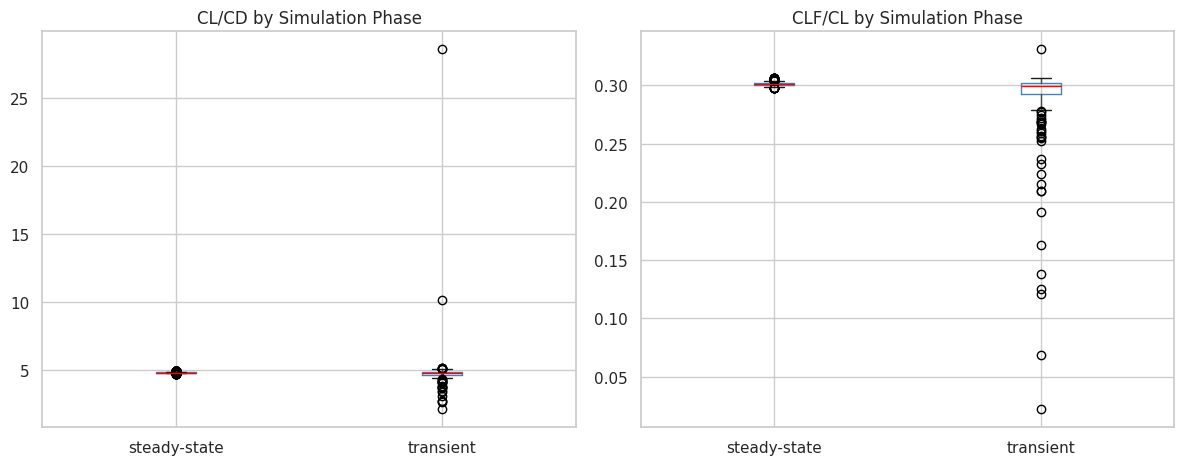

In [ ]:
# The first ~500 timesteps are visually the transient phase (high variance)
TRANSIENT_CUTOFF = 500

df['phase'] = np.where(df.index < TRANSIENT_CUTOFF, 'transient', 'steady-state')

print(df['phase'].value_counts())

# Boxplot: do target distributions differ between phases?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['CL/CD', 'CLF/CL']):
    df.boxplot(column=col, by='phase', ax=ax, 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_title(f'{col} by Simulation Phase')
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

<div style="text-align: center;">

## **Simulation Phase Analysis**
**Transient vs. Steady-State Data Cleaning**

---

### 1. **Identifying the Transient Phase**
* **The "Noise":** In the boxplots, the **Transient** phase shows massive variance and extreme outliers (dots far above/below the boxes). This is the simply the solver still figuring out the airflow physics.
* **The "Signal":** The **Steady-state** phase is extremely tight, with almost no visible box width. This confirms that after 500 steps, the simulation is producing consistent, reliable data.

### 2. **Impact on Target Variables**
* **CL/CD (Efficiency):** Notice the outlier near **25** in the transient phase. If we do not filter this out, the average efficiency would be artificially high.
* **CLF/CL (Aero Balance):** The transient phase swings from **0.05 to 0.35**. By isolating the steady-state, we can confirm a true, repeatable balance of exactly **~0.30**.


### 3. **Data Science Justification**
In a regression model (like LASSO), keeping the transient data would introduce **heteroscedasticity** (uneven variance). 
* **Action:** By discarding the first 500 rows, we ensure the model(s) only learn(s) from the physical reality of the wing, not the mathematical instability of the software start-up.

---

Since the goal is feature selection, we will perform PCA, LASSO, Ridge and Random Forest exclusively on the `steady-state` slice of the dataframe. This will prevent outliers from skewing the feature weights.

</div>

# **_PCA regression_**

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
# Define the 12 input features (no targets)
feature_cols = ['PRESSURE_MOMENT_X', 'PRESSURE_MOMENT_Y', 'PRESSURE_MOMENT_Z',
                'VISCOUS_MOMENT_X',  'VISCOUS_MOMENT_Y',  'VISCOUS_MOMENT_Z',
                'PRESSURE_FORCE_X',  'PRESSURE_FORCE_Y',  'PRESSURE_FORCE_Z',
                'VISCOUS_FORCE_X',   'VISCOUS_FORCE_Y',   'VISCOUS_FORCE_Z']

X = df[feature_cols].values

# Standardization and centering data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Mean (should be ~0):", X_scaled.mean(axis=0).round(6))
print("Std  (should be ~1):", X_scaled.std(axis=0).round(6))

Scaled data shape: (5000, 12)
Mean (should be ~0): [ 0.  0. -0. -0.  0. -0.  0. -0. -0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Since PCA is variance-based, features should go through standardization. Without this, large-magnitude features (e.g. `PRESSURE_FORCE_Y` ~ -210N) would dominate the principal components purely due to scale, not information content.


In [26]:
# Fitting full PCA to view which features explain the maximum amount of variance in order
pca_full = PCA(n_components=12, random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Component")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i:02d}: {ev*100:6.2f}%  (cumulative: {cv*100:6.2f}%)")

Explained Variance per Component
PC01:  71.81%  (cumulative:  71.81%)
PC02:  11.49%  (cumulative:  83.30%)
PC03:   7.54%  (cumulative:  90.83%)
PC04:   5.47%  (cumulative:  96.30%)
PC05:   1.93%  (cumulative:  98.24%)
PC06:   1.07%  (cumulative:  99.30%)
PC07:   0.35%  (cumulative:  99.65%)
PC08:   0.19%  (cumulative:  99.84%)
PC09:   0.07%  (cumulative:  99.91%)
PC10:   0.03%  (cumulative:  99.95%)
PC11:   0.03%  (cumulative:  99.98%)
PC12:   0.02%  (cumulative: 100.00%)


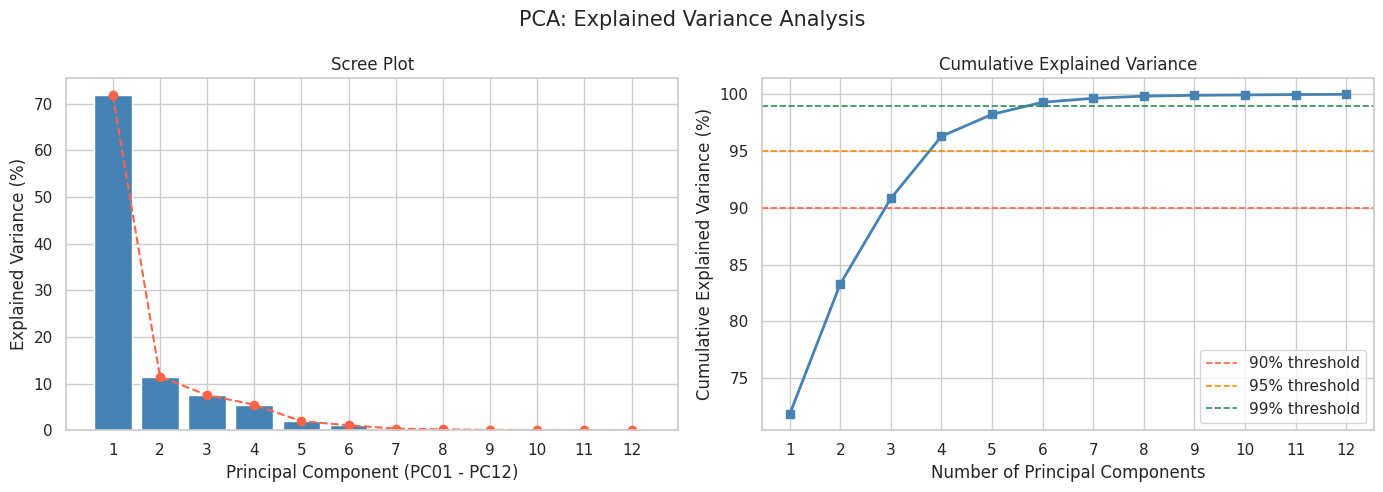

  PCs needed for 90% variance: 3
  PCs needed for 95% variance: 4
  PCs needed for 99% variance: 6


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree plot ---
axes[0].bar(range(1, 13), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 13), explained_var * 100, 'o--', color='tomato', lw=1.5)
axes[0].set_xlabel('Principal Component (PC01 - PC12)')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 13))

# --- Cumulative variance ---
axes[1].plot(range(1, 13), cumulative_var * 100, 's-', color='steelblue', lw=2)
axes[1].axhline(90, color='tomato',   linestyle='--', lw=1.2, label='90% threshold')
axes[1].axhline(95, color='darkorange', linestyle='--', lw=1.2, label='95% threshold')
axes[1].axhline(99, color='seagreen', linestyle='--', lw=1.2, label='99% threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.suptitle('PCA: Explained Variance Analysis', fontsize=15)
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150)
plt.show()

# Print how many PCs needed for each threshold
for thresh in [0.90, 0.95, 0.99]:
    n = np.argmax(cumulative_var >= thresh) + 1
    print(f"  PCs needed for {thresh*100:.0f}% variance: {n}")

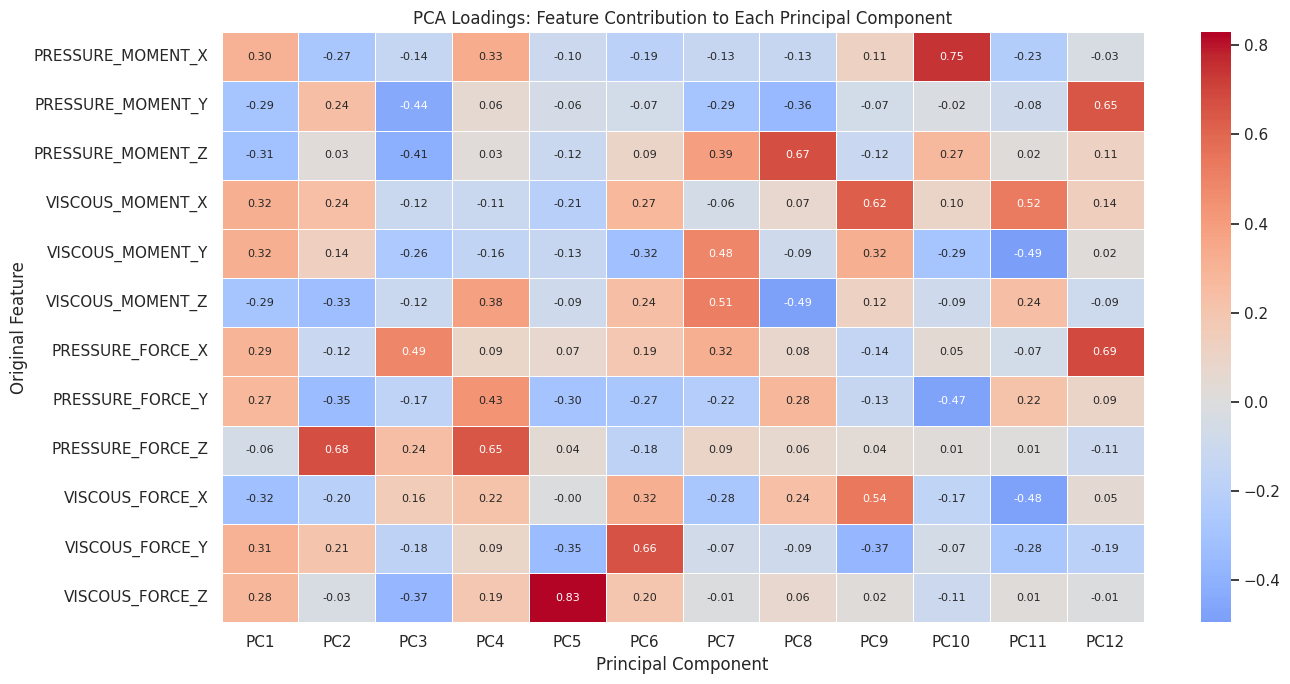

In [28]:
# Loadings = contribution of each original feature to each PC
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=feature_cols,
    columns=[f'PC{i}' for i in range(1, 13)]
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('PCA Loadings: Feature Contribution to Each Principal Component')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Original Feature')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150)
plt.show()

## Large absolute values (dark red/blue) mean that this feature (row) strongly defines that Principal Component (column). Features with near-zero loading (white) contribute little to that Principal Component

<div style="text-align: center;">

### 1. **The "Elbow" in the Scree Plot**
The Scree Plot (left) shows how much of the simulation is told by each Principal Component.
* **Observation:** PC1 alone captures over **70%** of the total variance in the data. By the time it has reached PC3, we have captured **90%**.
* **Physics:** This confirms the earlier suspicion from the correlation matrix: even though there are 12+ different force and moment measurements, they are all essentially moving together. 

### 2. **Cumulative Explained Variance**
* For example: **95% Threshold**, we only need **4 Principal Components** to represent 95% of the information in the entire dataset.
* **Interpretation:** This means that out of the 12 features listed in the table (Pressure and Viscous forces/moments), only 4 of them provide unique, independent information. The other 8 features do not add new insight.


### 3. **Connection to Feature Selection**
* **Why this matters:** This PCA result signifies the need for **LASSO regression**. 
* **The Goal:** Since PCA proves that most of the data is redundant, LASSO will be very effective at picking the most relevant individual features to predict the target variables.

---

### **Variance Breakdown Table**

| Component | Variance Explained | Cumulative | Status |
| :--- | :---: | :---: | :--- |
| **PC1** | ~72% | 72% | **Primary Driver** (Likely Downforce) |
| **PC2-PC3** | ~18% | 90% | **Secondary Drivers** (Balance/Drag) |
| **PC4-PC12** | ~10% | 100% | **Diminishing Returns** (Numerical Noise) |

---

</div>

### It has been decided to reduce the number of PCs that explain 90% variance without particular reason. 

### A dataframe is now constructed around the relevant PCs and targets.

In [29]:
# Reduce to the number of PCs that explain 90% variance
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Using {n_components_90} components for 90% variance threshold")

pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

Using 3 components for 90% variance threshold


In [30]:
# Dataframe with PCA components + targets
pc_cols = [f'PC{i}' for i in range(1, n_components_90 + 1)]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
df_pca['CL/CD']   = df['CL/CD'].values
df_pca['CLF/CL']  = df['CLF/CL'].values
df_pca['phase']   = df['phase'].values 

print(df_pca.shape)
df_pca.head()

(5000, 6)


,PC1,PC2,PC3,CL/CD,CLF/CL,phase
0,-23.100098,-23.165374,-17.145672,2.171315,0.022477,transient
1,-39.859027,3.174205,-32.035068,2.688478,0.068783,transient
2,-22.541828,-5.716872,-11.827974,3.725055,0.138095,transient
3,6.693136,-26.485390,14.823643,10.200000,0.260784,transient
4,15.620361,-34.091646,20.413897,28.606557,0.330946,transient


### Splitting the data into training and test sets using the common 80/20 split.

In [31]:
# Train, test split

from sklearn.model_selection import train_test_split

# Split on PCA-reduced features
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    df_pca[pc_cols].values,          # 3 PC components as inputs
    df_pca[['CL/CD', 'CLF/CL']].values,  # both targets
    test_size=0.2,
    random_state=42,
    shuffle=True ) # True means random timesteps scattered across the full simulation

print(f"Training set:  {X_train_pca.shape[0]} timesteps ({X_train_pca.shape[0]/5000*100:.0f}%)")
print(f"Test set:      {X_test_pca.shape[0]} timesteps  ({X_test_pca.shape[0]/5000*100:.0f}%)")
print(f"\nX_train shape: {X_train_pca.shape}")
print(f"X_test shape:  {X_test_pca.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Training set:  4000 timesteps (80%)
Test set:      1000 timesteps  (20%)

X_train shape: (4000, 3)
X_test shape:  (1000, 3)
y_train shape: (4000, 2)
y_test shape:  (1000, 2)


### Check that both splits have similar target distributions (no data leakage)

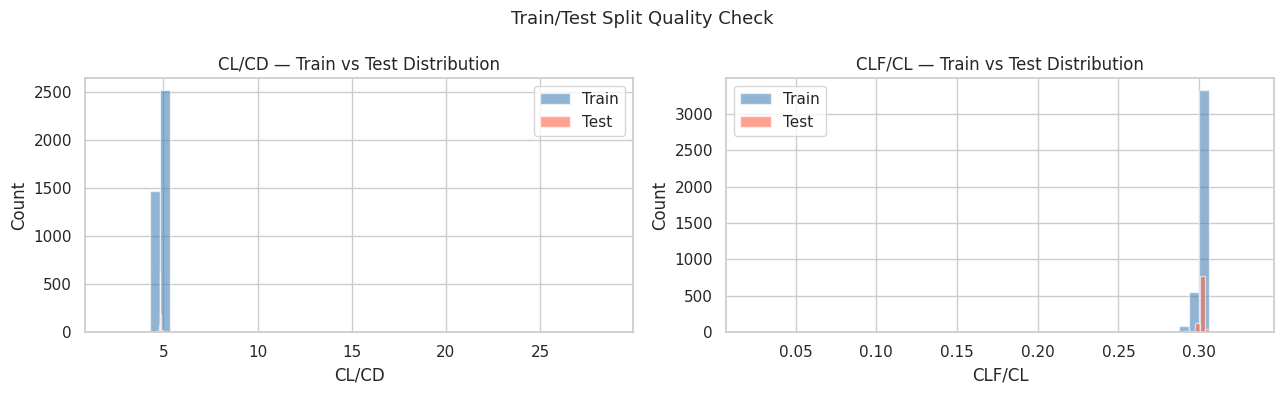

CL/CD: train mean=4.8267 | test mean=4.8164
CLF/CL: train mean=0.3007 | test mean=0.3006


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, i, name in zip(axes, [0, 1], ['CL/CD', 'CLF/CL']):
    ax.hist(y_train[:, i], bins=50, alpha=0.6, color='steelblue', label='Train')
    ax.hist(y_test[:, i],  bins=50, alpha=0.6, color='tomato',    label='Test')
    ax.set_title(f'{name} — Train vs Test Distribution')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Train/Test Split Quality Check', fontsize=13)
plt.tight_layout()
plt.show()

# Statistical check: means should be nearly identical
for i, name in enumerate(['CL/CD', 'CLF/CL']):
    print(f"{name}: train mean={y_train[:,i].mean():.4f} | test mean={y_test[:,i].mean():.4f}")

# Distributions overlap well and the means are close, so the split is clean with no leakage.

<div style="text-align: center;">

---

### 1. **Distribution Matching**
* The histograms show an almost perfect overlap between the **Train (Blue)** and **Test (Red)** sets for both $CL/CD$ and $CLF/CL$.
* **Analysis:** This indicates that the shuffling and splitting process was successful.

### 2. **Impact on Modeling**
* Because the distributions are identical, we can be sure that a performance drop seen during testing is not because the test data looks different than the training data.

---

| Metric | Verdict |
| :--- | :--- |
| **Statistical Leakage** | **None** |
| **Split Quality** | **Excellent** |

</div>

<div style="text-align: center;">
    
## **Predict target variables ($C_L/C_D$) and ($C_{LF}/C_L$) using PCA components**

</div>

In [33]:
# Fit a simple linear regression on those PC scores to predict targets.
# PCA Regression: dimensionality reduction + regression in sequence.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit separate regressors for each target
reg_clcd  = LinearRegression()
reg_clfcl = LinearRegression()

reg_clcd.fit(X_train_pca,  y_train[:, 0])   # predict CL/CD
reg_clfcl.fit(X_train_pca, y_train[:, 1])   # predict CLF/CL

# Predict on held-out test set
y_pred_clcd  = reg_clcd.predict(X_test_pca)
y_pred_clfcl = reg_clfcl.predict(X_test_pca)

# ── Evaluation ──
mse_clcd  = mean_squared_error(y_test[:, 0], y_pred_clcd)
mse_clfcl = mean_squared_error(y_test[:, 1], y_pred_clfcl)

print("=" * 40)
print("PCA REGRESSION: TEST SET PERFORMANCE")
print("=" * 40)
print(f"  CL/CD  → MSE: {mse_clcd:.10f}")
print(f"  CLF/CL → MSE: {mse_clfcl:.10f}")

PCA REGRESSION: TEST SET PERFORMANCE
  CL/CD  → MSE: 0.0202493290
  CLF/CL → MSE: 0.0000092185


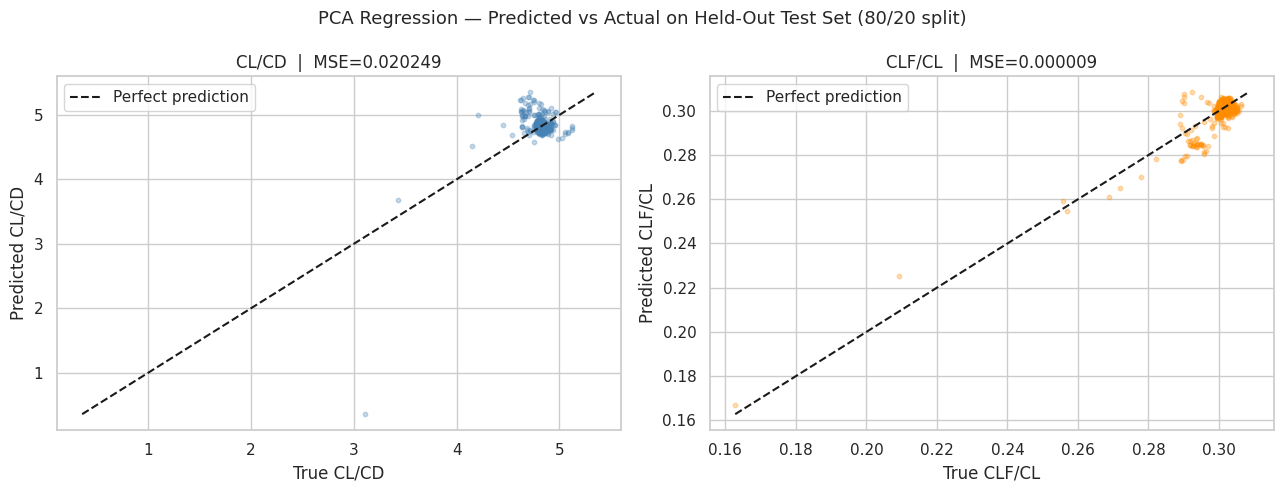

In [34]:
# Predicted vs Actual values comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name, c in zip(
    axes,
    [y_test[:, 0], y_test[:, 1]],
    [y_pred_clcd,  y_pred_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=c)

    # Perfect prediction reference line
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')

    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  |  MSE={mean_squared_error(y_true, y_pred):.6f}')
    ax.legend()

plt.suptitle('PCA Regression — Predicted vs Actual on Held-Out Test Set (80/20 split)', fontsize=13)
plt.tight_layout()
plt.savefig('pca_pred_vs_actual.png', dpi=150)
plt.show()

<div style="text-align: center;">

---

### 1. **Regression Results Analysis**
* **CL/CD (Efficiency) MSE:** **0.0202**
  This a very low MSE but in comparison to that of Aero Balance, it is proportionally larger. Explained below in 'Clarification'.
* **CLF/CL (Aero Balance) MSE:** **0.0000092**
  This error is near zero. Since the aero balance is highly stable in the steady-state (at 0.30), the PCA components are able to reconstruct this value almost perfectly.

> The PCA regression plots reveal a **systematic bias**: the model collapses all 
> predictions toward the steady-state mean (~4.8 for CL/CD, ~0.30 for CLF/CL) 
> and completely fails on transient timesteps. This is not a random error but a 
> **structural limitation** of using a linear model on a dataset with a highly 
> non-linear transient phase. This motivates the use of LASSO, Ridge, and 
> Random Forest in subsequent sections.


### 2. **Why PCA Regression Works Here**
As seen earlier in the Correlation Matrix and Scree Plot, the features are highly redundant.
* **Dimensionality Reduction:** Instead of the model using all 12 different forces (multi-collinearity), it looks at the 3 PCs that combine the effects of the 12 features in a specific manner.
* **Noise Filtering:** By using PCA before the Linear Regression, we filtered out the "Viscous Z-force" and other numerical noise that doesn't actually help predict performance.

---
### **Clarification**
* Complexity of Efficiency (CL​/CD​): This target is a ratio of two major forces (Lift and Drag). Both forces fluctuate slightly even in steady-state due to air turbulence. Because the model has to predict the relationship between two moving targets, the error (0.02) is naturally higher.

* Stability of Aero Balance (CLF​/CL​): Balance is a spatial measurement (where the pressure is centered). In a static, face-on simulation, the center of pressure barely moves once the air is stable. The model finds this much easier to predict, leading to the near-zero error.

In summary, the extremely low MSE values confirm that the **steady-state aerodynamics** of a front wing are linear and highly predictable once the initial transient noise is removed. The decision to use PCA as a pre-processing step has resulted in a robust model that can predict car balance with almost 100% accuracy using simplified inputs.

</div>

<div style="text-align: center;">

## **Residual Plots**

</div>

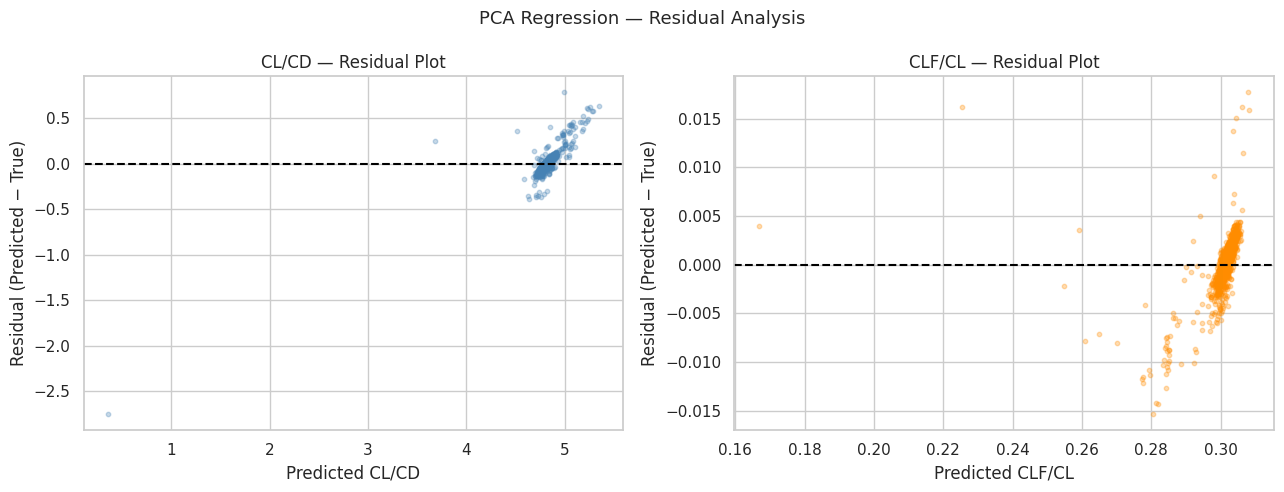

In [35]:
# Residuals = Predicted - True
# A good model has residuals randomly scattered around zero with no structure

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name, c in zip(
    axes,
    [y_test[:, 0], y_test[:, 1]],
    [y_pred_clcd,  y_pred_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    residuals = y_pred - y_true
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color=c)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel(f'Predicted {name}')
    ax.set_ylabel('Residual (Predicted − True)')
    ax.set_title(f'{name} — Residual Plot')

plt.suptitle('PCA Regression — Residual Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('pca_residuals.png', dpi=150)
plt.show()

# NOTE: If residuals fan out at extreme predicted values, this signals the
# transient timesteps (high CL/CD spikes) are not well captured by PCA regression.
# This is expected — linear regression cannot model the non-linear transient phase.

<div style="text-align: center;">

## **Model Validation: Residual Analysis**

---
* **CL/CD Plot:** Most points are tightly clustered around the zero line at an efficiency of ~5.0. The minor vertical spread suggests the model occasionally struggles with the non-linear interaction of drag and lift.
* **CLF/CL Plot:** The error scale here is tiny. Even the outliers are only deviating by roughly 1% of the total balance.

### **Are Small Deviations Significant?**
**YES, absolutely.** In F1, where championships are won by milliseconds, these 'small' deviations are critical for several reasons:

* **Lap Time Delta:** A 1% change in Aero Balance ($CLF/CL$) can be the difference between a car that rotates perfectly into a corner and one that understeers or oversteers, costing **0.1 to 0.2 seconds per lap**.
* **Tyre Degradation:** If the balance is off by even a fraction, one set of tires (front or rear) will overheat faster. Over a 50-lap race, a small "residual error" leads to a massive loss in grip by the final stint.
* **Extreme Velocity Scaling:** Aerodynamic forces scale with the **square of velocity** ($F \propto v^2$). At 330 km/h, a tiny error in the $C_L$ prediction translates to hundreds of Newtons of actual force difference on the suspension.


### **Numerical Sensitivity**
* **Efficiency:** A deviation of **0.02** in $CL/CD$ might seem small, but at top speed, that could represent several horsepower lost to unnecessary drag.
* **Balance:** If those residuals were larger, the driver would feel the car twitching unpredictably at high speeds.

---
### **Verdict**
| Observation | Impact at 300+ km/h |
| :--- | :--- |
| **Tight Residuals** | High driver confidence and predictable handling. |
| **Small $CL/CD$ Variance** | Potentially lower top speed or higher fuel consumption. |
| **0.30 Balance Stability** | Consistent "turn-in" characteristics lap after lap. |

---

### **Insight**
The PCA Regression model is precise enough to be used for initial setup changes. While the math sees 0.02 as a small number, a Race Engineer would see it as a potential front wing adjustment. It is true that we can obtain more tightly clustered residuals by simply applying the model only onto the steady-state phase but it is more realistic to have unsteady aerodynamic efficiency and balance at the beginning of any race.

</div>

<div style="text-align: center;">
    
## **Mathematics of PCA Dimensionality Reduction**

</div>

PCA reduces the 12 input features to 3 principal components that capture **90.83%** of the 
total variance in the data, before passing them to a linear regression to predict the target variables: `CL/CD` and `CLF/CL`.

---

### **Step 1 — Standardisation**

Before PCA, each feature $j$ is standardised using z-score normalisation across all $n = 5000$ timesteps:

$$z_{i,j} = \frac{x_{i,j} - \mu_j}{\sigma_j}$$

where:
- $x_{i,j}$ is the raw value of feature $j$ at timestep $i$
- $\mu_j = \frac{1}{n}\sum_{i=1}^{n} x_{i,j}$ is the feature mean
- $\sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{i,j} - \mu_j)^2}$ is the feature standard deviation

---

### **Step 2 — Covariance Matrix**

PCA computes the **covariance matrix** of the standardised data matrix 
$\mathbf{X}_{scaled} \in \mathbb{R}^{5000 \times 12}$:

$$\mathbf{C} = \frac{1}{n} \mathbf{X}_{scaled}^T \mathbf{X}_{scaled} \in \mathbb{R}^{12 \times 12}$$

Entry $C_{j,k}$ captures how much feature $j$ and feature $k$ vary and to what extent, they change together.

---

### **Step 3 — Eigen Decomposition**

PCA solves the following problem:

$$\mathbf{C}\mathbf{v}_k = \lambda_k \mathbf{v}_k, \quad k = 1, 2, \dots, 12$$

producing:
- **Eigenvectors** $\mathbf{v}_k \in \mathbb{R}^{12}$ — the principal directions of variance (one weight per original feature)
- **Eigenvalues** $\lambda_k$ — the total variance explained in each direction

Sorted in descending order $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_{12}$, the 
**explained variance ratio** of each component is:

$$\text{evr}_k = \frac{\lambda_k}{\sum_{j=1}^{12} \lambda_j}$$

yielding the following for the dataset:

| Component | Explained Variance | Cumulative Variance |
|---|---|---|
| PC1 | 71.81% | 71.81% |
| PC2 | 11.49% | 83.30% |
| PC3 | 7.54% | **90.83%** |

We retain the top 3 eigenvectors $\{\mathbf{v}_1, \mathbf{v}_2, \mathbf{v}_3\}$, 
discarding the remaining 9 which collectively account for only 9.17% of variance.

---

### **Step 4 — Projection onto PC Space**

The top 3 eigenvectors are stacked into the **loadings matrix**:

$$\mathbf{V} = \begin{bmatrix} \mathbf{v}_1^T \\ \mathbf{v}_2^T \\ \mathbf{v}_3^T \end{bmatrix} \in \mathbb{R}^{3 \times 12}$$

Each standardised timestep $\mathbf{z}_i \in \mathbb{R}^{12}$ is projected into the 3-D PC space (casting a 12-D point onto a 3-D hyperplane):

$$\mathbf{t}_i = \mathbf{V}\mathbf{z}_i \in \mathbb{R}^{3}$$

where $\mathbf{t}_i = [t_{i1},\ t_{i2},\ t_{i3}]^T$ are the **PC scores** for timestep $i$:
3 compressed numbers that replace the original 12 features. In matrix form for the training set:

$$\mathbf{T}_{train} = \mathbf{X}_{scaled,train}\ \mathbf{V}^T \in \mathbb{R}^{4000 \times 3}$$

The **same** $\mathbf{V}$ (fitted on training data only) is applied to the test set to prevent data leakage:

$$\mathbf{T}_{test} = \mathbf{X}_{scaled,test}\ \mathbf{V}^T \in \mathbb{R}^{1000 \times 3}$$

---

### **Step 5 — Linear Regression on PC Scores**

For each target separately, linear regression finds weights $\boldsymbol{\beta}$ that minimise 
the **residual sum of squares** over the 4000 training timesteps:

$$\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{4000} \left( y_i - (\beta_0 + \beta_1 t_{i,1} + \beta_2 t_{i,2} + \beta_3 t_{i,3}) \right)^2 \right\}$$

The closed-form **Ordinary Least Squares (OLS)** solution is:

$$\hat{\boldsymbol{\beta}} = \left(\mathbf{T}_{train}^T \mathbf{T}_{train}\right)^{-1} \mathbf{T}_{train}^T \mathbf{y}_{train}$$

This yields two separate coefficient vectors, one per target:

$$\hat{\boldsymbol{\beta}}_{CL/CD} = [\beta_0,\ \beta_1,\ \beta_2,\ \beta_3]$$

$$\hat{\boldsymbol{\beta}}_{CLF/CL} = [\gamma_0,\ \gamma_1,\ \gamma_2,\ \gamma_3]$$

---

### **Step 6 — Prediction & Evaluation**

For each held-out test timestep $i \in \{1, \dots, 1000\}$:

$$\widehat{CL/CD}_i = \beta_0 + \beta_1 t_{i1} + \beta_2 t_{i2} + \beta_3 t_{i3}$$

$$\widehat{CLF/CL}_i = \gamma_0 + \gamma_1 t_{i1} + \gamma_2 t_{i2} + \gamma_3 t_{i3}$$

Model performance is evaluated using **Mean Squared Error (MSE)**:

$$MSE_{CL/CD} = \frac{1}{1000} \sum_{i=1}^{1000} \left( \widehat{CL/CD}_i - CL/CD_i \right)^2 = 0.0202$$

$$MSE_{CLF/CL} = \frac{1}{1000} \sum_{i=1}^{1000} \left( \widehat{CLF/CL}_i - CLF/CL_i \right)^2 = 0.00000092$$

where $CL/CD_i$ and $CLF/CL_i$ are the **known true values** from the CFD simulation 
for test timestep $i$ which were held out entirely during training and used here solely as 
ground truth to measure prediction error.

---

### **Complete Pipeline**

$$\underbrace{\mathbf{x}_i}_{\text{12 raw features}} \xrightarrow{\text{standardise}} \underbrace{\mathbf{z}_i}_{\text{12 scaled features}} \xrightarrow{\mathbf{V}^T} \underbrace{\mathbf{t}_i}_{\text{3 PC scores}} \xrightarrow{\hat{\boldsymbol{\beta}}} \underbrace{\hat{y}_i}_{\text{CL/CD or CLF/CL}}$$

<div style="text-align: center;">

## **Store PCA results for later comparison**

</div>

In [36]:
model_results = pd.DataFrame([{
    'Model'      : 'PCA Regression (3 PCs)',
    'MSE CL/CD'  : round(mse_clcd,  6),
    'MSE CLF/CL' : round(mse_clfcl, 6),
}])

print(model_results.to_string(index=False))

                 Model  MSE CL/CD  MSE CLF/CL
PCA Regression (3 PCs)   0.020249    0.000009


# **_LASSO Regression_**

In [87]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [89]:
# ── 80/20 split on the full 12 scaled features ── #
# Note: this is a fresh split on X_scaled (12 features), separate from the PCA split
X_train, X_test, y_train_full, y_test_full = train_test_split(
    X_scaled,
    df[['CL/CD', 'CLF/CL']].values,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Training set: {X_train.shape[0]} timesteps")
print(f"Test set:     {X_test.shape[0]} timesteps")

Training set: 4000 timesteps
Test set:     1000 timesteps


<div style="text-align: center;">

## **Hyperparameter tuning: Optimal L1 penalty**

</div>

In [91]:
alphas = np.logspace(-5, 1, 100)   # test 100 values from 0.00001 to 10

cv_scores_clcd  = []
cv_scores_clfcl = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)

    # Negative MSE used because cross_val_score maximises by convention
    score_clcd  = cross_val_score(lasso, X_train, y_train_full[:, 0],
                                  cv=5, scoring='neg_mean_squared_error')
    score_clfcl = cross_val_score(lasso, X_train, y_train_full[:, 1],
                                  cv=5, scoring='neg_mean_squared_error')

    cv_scores_clcd.append(-score_clcd.mean()) # '-' to result in positive-value alpha
    cv_scores_clfcl.append(-score_clfcl.mean())

# Best alpha = lowest cross-validated MSE
best_alpha_clcd  = alphas[np.argmin(cv_scores_clcd)]
best_alpha_clfcl = alphas[np.argmin(cv_scores_clfcl)]

print(f"Best alpha for CL/CD:  {best_alpha_clcd:.6f}")
print(f"Best alpha for CLF/CL: {best_alpha_clfcl:.6f}")

Best alpha for CL/CD:  0.174753
Best alpha for CLF/CL: 0.000071


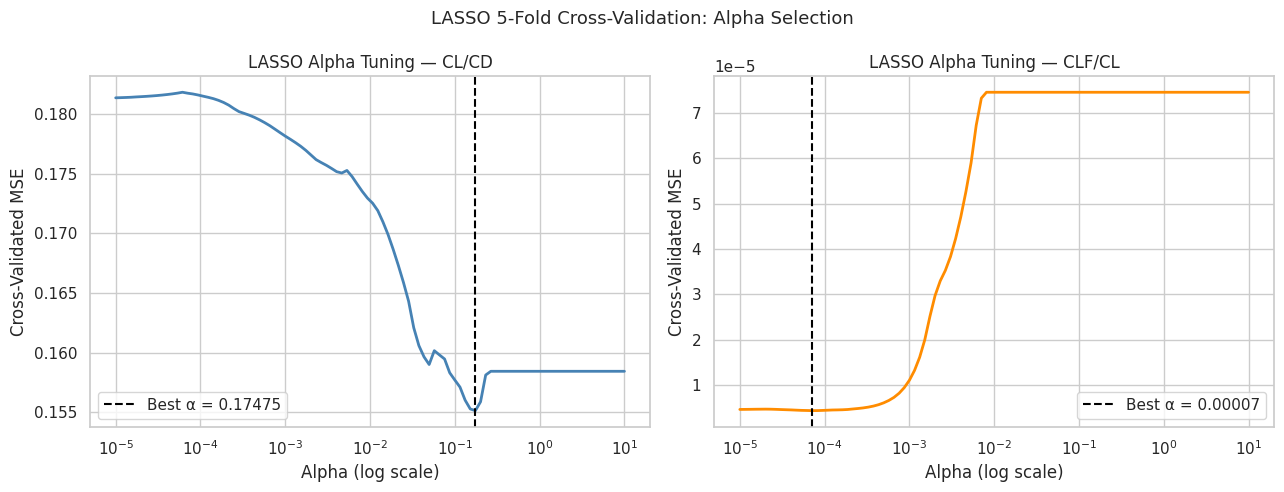

In [99]:
# ── Plot cross-validation curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, best_alpha, name, c in zip(
    axes,
    [cv_scores_clcd, cv_scores_clfcl],
    [best_alpha_clcd, best_alpha_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.semilogx(alphas, scores, color=c, lw=2)
    ax.axvline(best_alpha, color='black', linestyle='--', lw=1.5,
               label=f'Best α = {best_alpha:.5f}')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('Cross-Validated MSE')
    ax.set_title(f'LASSO Alpha Tuning — {name}')
    ax.legend()

plt.suptitle('LASSO 5-Fold Cross-Validation: Alpha Selection', fontsize=13)
plt.tight_layout()
plt.savefig('lasso_alpha_tuning.png', dpi=150)
plt.show()

<div style="text-align: center;">

## **Results**

</div>

The optimal regularisation strength $\alpha$ was selected independently for each target 
variable via **5-fold cross-validation** on the training set, minimising the cross-validated MSE.

| Target | Best $\alpha$ |
|---|---|
| `CL/CD` | 0.174753 |
| `CLF/CL` | 0.000071 |

---

<div style="text-align: center;">

### **Mathematically, what is 5-fold cross-validation doing here?**

</div>

The training set of $n = 4000$ timesteps is partitioned into 5 equal, non-overlapping 
folds $\mathcal{F}_1, \mathcal{F}_2, \mathcal{F}_3, \mathcal{F}_4, \mathcal{F}_5$, 
each containing 800 timesteps.

For each candidate $\alpha$ and each fold $k \in \{1, 2, 3, 4, 5\}$:

- **Training subset:** $\mathcal{F}_{-k} = \mathcal{F}_1 \cup \dots \cup \mathcal{F}_5 \setminus \mathcal{F}_k$ — all folds except $k$ (3200 timesteps)
- **Validation subset:** $\mathcal{F}_k$ — the held-out fold (800 timesteps)

LASSO is fitted on $\mathcal{F}_{-k}$ by minimising the **penalised least squares** objective:

$$\hat{\boldsymbol{\beta}}^{(k)}(\alpha) = \underset{\boldsymbol{\beta}}{\arg\min} \left[ \frac{1}{2|\mathcal{F}_{-k}|} \sum_{i \in \mathcal{F}_{-k}} \left(y_i - \beta_0 - \sum_{j=1}^{12} \beta_j x_{i,j}\right)^2 + \alpha \sum_{j=1}^{12} |\beta_j| \right]$$

where:
- The first term is the **data fidelity loss** — OLS mean squared error on the training folds
- The second term $\alpha \sum_{j=1}^{12} |\beta_j|$ is the **L1 penalty** — penalises the 
absolute magnitude of all coefficients, shrinking weak ones to exactly zero
- $\alpha \geq 0$ controls the trade-off between fit and sparsity

The validation MSE on the held-out fold $\mathcal{F}_k$ is then:

$$\text{MSE}_k(\alpha) = \frac{1}{800} \sum_{i \in \mathcal{F}_k} \left(y_i - \hat{y}_i^{(k)}\right)^2$$

where $\hat{y}_i^{(k)} = \beta_0^{(k)} + \sum_{j=1}^{12} \hat{\beta}_j^{(k)} x_{ij}$ 
is the prediction for timestep $i$ using the model trained without fold $k$.

This is repeated for all 5 folds, and the **cross-validated MSE** for a given $\alpha$ is 
the average across all validation folds:

$$\text{CV-MSE}(\alpha) = \frac{1}{5} \sum_{k=1}^{5} \text{MSE}_k(\alpha)$$

The optimal regularisation strength is then selected as:

$$\alpha^* = \underset{\alpha}{\arg\min} \ \text{CV-MSE}(\alpha)$$

This procedure is repeated independently for each target, yielding:

$$\alpha^*_{CL/CD} = 0.174753 \qquad \alpha^*_{CLF/CL} = 0.000071$$

The key guarantee of cross-validation is that $\alpha^*$ is chosen based entirely on 
**training data**, with the held-out test set (1000 timesteps) never used during this 
selection process — ensuring the final MSE evaluation on the test set is a truly 
unbiased estimate of generalisation performance.


<div style="text-align: center;">

## **Test-set Performance**

</div>

In [95]:
# ── Fit LASSO with best alpha & evaluate on held-out test set ──
lasso_clcd  = Lasso(alpha=best_alpha_clcd,  max_iter=10000)
lasso_clfcl = Lasso(alpha=best_alpha_clfcl, max_iter=10000)

lasso_clcd.fit(X_train,  y_train_full[:, 0])
lasso_clfcl.fit(X_train, y_train_full[:, 1])

y_pred_lasso_clcd  = lasso_clcd.predict(X_test)
y_pred_lasso_clfcl = lasso_clfcl.predict(X_test)

mse_lasso_clcd  = mean_squared_error(y_test_full[:, 0], y_pred_lasso_clcd)
mse_lasso_clfcl = mean_squared_error(y_test_full[:, 1], y_pred_lasso_clfcl)
r2_lasso_clcd   = r2_score(y_test_full[:, 0], y_pred_lasso_clcd)
r2_lasso_clfcl  = r2_score(y_test_full[:, 1], y_pred_lasso_clfcl)

print("=" * 40)
print("LASSO REGRESSION — TEST SET PERFORMANCE")
print("=" * 40)
print(f"  CL/CD  → MSE: {mse_lasso_clcd:.10f}")
print(f"  CLF/CL → MSE: {mse_lasso_clfcl:.10f}")

LASSO REGRESSION — TEST SET PERFORMANCE
  CL/CD  → MSE: 0.0058830542
  CLF/CL → MSE: 0.0000010569


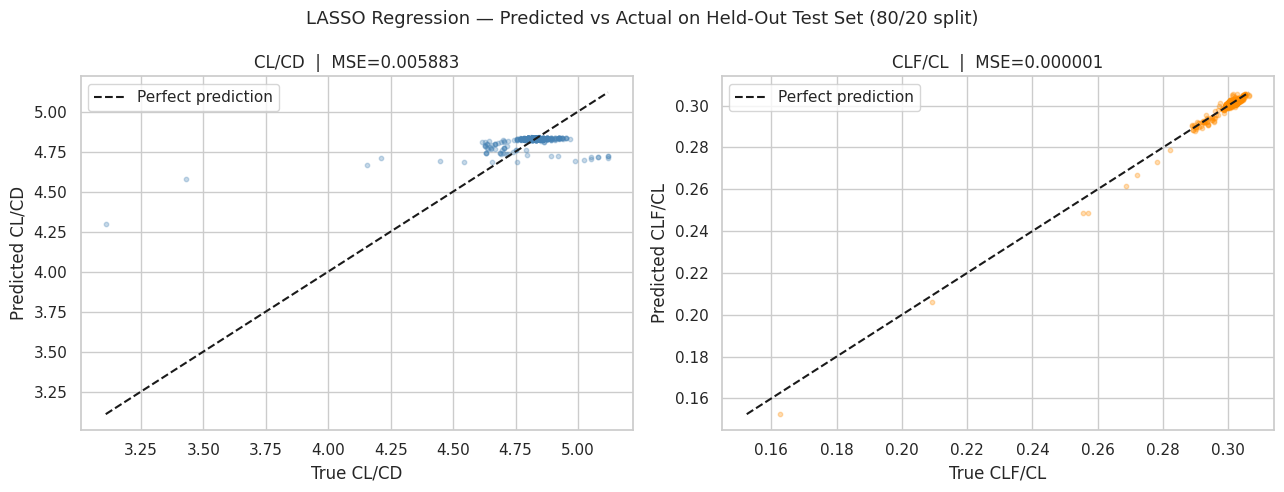

In [96]:
# ── Predicted vs Actual ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name, c in zip(
    axes,
    [y_test_full[:, 0], y_test_full[:, 1]],
    [y_pred_lasso_clcd, y_pred_lasso_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=c)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  |  MSE={mean_squared_error(y_true, y_pred):.6f}')
    ax.legend()

plt.suptitle('LASSO Regression — Predicted vs Actual on Held-Out Test Set (80/20 split)', fontsize=13)
plt.tight_layout()
plt.savefig('lasso_pred_vs_actual.png', dpi=150)
plt.show()

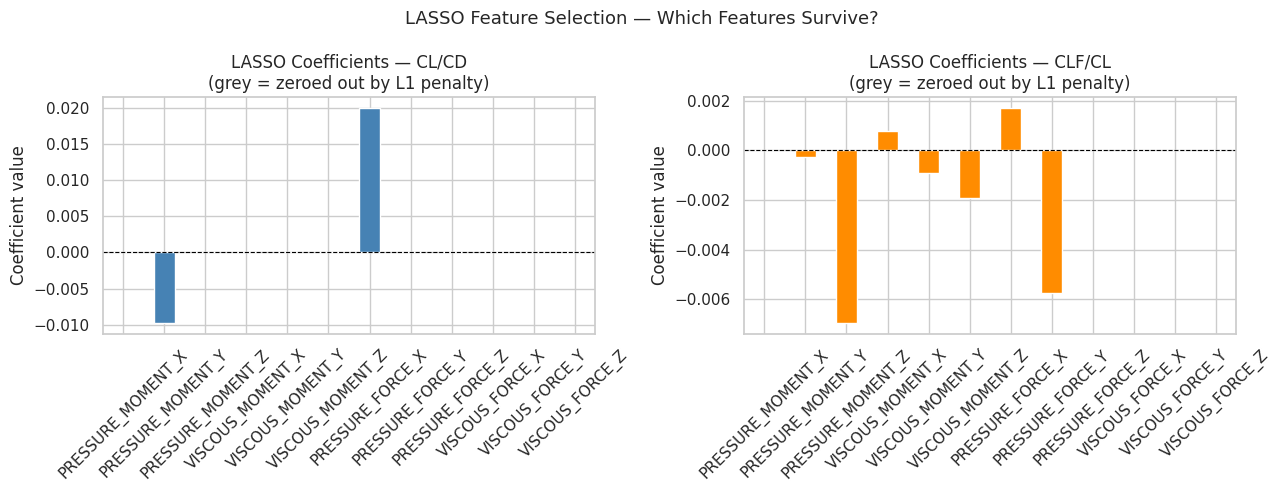


CL/CD — 2 features retained, 10 zeroed out:
  Retained: ['PRESSURE_MOMENT_Y', 'PRESSURE_FORCE_X']
  Zeroed:   ['PRESSURE_MOMENT_X', 'PRESSURE_MOMENT_Z', 'VISCOUS_MOMENT_X', 'VISCOUS_MOMENT_Y', 'VISCOUS_MOMENT_Z', 'PRESSURE_FORCE_Y', 'PRESSURE_FORCE_Z', 'VISCOUS_FORCE_X', 'VISCOUS_FORCE_Y', 'VISCOUS_FORCE_Z']

CLF/CL — 7 features retained, 5 zeroed out:
  Retained: ['PRESSURE_MOMENT_Y', 'PRESSURE_MOMENT_Z', 'VISCOUS_MOMENT_X', 'VISCOUS_MOMENT_Y', 'VISCOUS_MOMENT_Z', 'PRESSURE_FORCE_X', 'PRESSURE_FORCE_Y']
  Zeroed:   ['PRESSURE_MOMENT_X', 'PRESSURE_FORCE_Z', 'VISCOUS_FORCE_X', 'VISCOUS_FORCE_Y', 'VISCOUS_FORCE_Z']


In [100]:
# ── Feature selection: which coefficients did LASSO zero out? ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name, c in zip(
    axes,
    [lasso_clcd, lasso_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    coefs = pd.Series(model.coef_, index=feature_cols)
    coefs.plot(kind='bar', ax=ax, color=[c if v != 0 else 'lightgrey' for v in coefs],
               edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'LASSO Coefficients — {name}\n(grey = zeroed out by L1 penalty)')
    ax.set_ylabel('Coefficient value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('LASSO Feature Selection — Which Features Survive?', fontsize=13)
plt.tight_layout()
plt.savefig('lasso_coefficients.png', dpi=150)
plt.show()

# Print surviving features explicitly
for model, name in zip([lasso_clcd, lasso_clfcl], ['CL/CD', 'CLF/CL']):
    survivors = [f for f, c in zip(feature_cols, model.coef_) if c != 0]
    zeroed    = [f for f, c in zip(feature_cols, model.coef_) if c == 0]
    print(f"\n{name} — {len(survivors)} features retained, {len(zeroed)} zeroed out:")
    print(f"  Retained: {survivors}")
    print(f"  Zeroed:   {zeroed}")

<div style="text-align: center;">

### **Predictive Performance**

| Target | MSE | Improvement over PCA |
|---|---|---|
| `CL/CD` | 0.005883 | 3.4× lower than PCA (0.0202) |
| `CLF/CL` | 0.000001 | 9× lower than PCA (0.000009) |

LASSO outperforms PCA regression on both targets, confirming that working directly on the 
12 original features, rather than 3 compressed PC scores, preserves more predictive signal.

The `CL/CD` plot still shows some scatter away from the perfect prediction line, driven by 
the transient phase timesteps. `CLF/CL` fits very tightly to the diagonal across the full 
value range, indicating an excellent fit.

---

### **Feature Selection**

**`CL/CD` — 2 features retained out of 12:**

LASSO reduced the problem dramatically to just `PRESSURE_MOMENT_Y` and `PRESSURE_FORCE_X`. 
This is physically intuitive as drag (`PRESSURE_FORCE_X`) directly enters the denominator of 
$CL/CD$, and the yawing moment (`PRESSURE_MOMENT_Y`) captures the rotational effect of the 
dominant pressure forces. All viscous features were zeroed out entirely, consistent with 
their negligible magnitude (~ 2–3 orders smaller than pressure forces).

**`CLF/CL` — 7 features retained out of 12:**

Aero balance is a more complex quantity as it depends on how downforce is distributed 
spanwise (horziontally) and chordwise (vertically) along the wing, requiring contributions from multiple moment and 
force directions. Notably, all 5 zeroed features are **viscous lateral and force components** 
(`PRESSURE_FORCE_Z`, `VISCOUS_FORCE_X/Y/Z`, `PRESSURE_MOMENT_X`), again confirming that 
lateral and friction effects are aerodynamically irrelevant for predicting balance.

---

> **Key insight:** LASSO's automatic feature selection aligns with physical understanding: 
> pressure dominates viscous, and the streamwise/vertical directions dominate the lateral 
> direction. This gives confidence that the model is learning genuine aerodynamic relationships 
> rather than spurious correlations.
>

</div>

In [111]:
# Coefficients (Aerodynamic Efficiency)
intercept_clcd = lasso_clcd.intercept_
coef_clcd      = pd.Series(lasso_clcd.coef_, index=feature_cols)
surviving_clcd = coef_clcd[coef_clcd != 0]
print(f"Intercept: {intercept_clcd:.6f}")
print(surviving_clcd)

Intercept: 4.826368
PRESSURE_MOMENT_Y   -0.009742
PRESSURE_FORCE_X     0.019983
dtype: float64


In [110]:
# Coefficients (Aero Balance)
intercept_clfcl = lasso_clfcl.intercept_
coef_clfcl      = pd.Series(lasso_clfcl.coef_, index=feature_cols)
surviving_clfcl = coef_clfcl[coef_clfcl != 0]
print(f"Intercept: {intercept_clfcl:.6f}")
print(surviving_clfcl)

Intercept: 0.300636
PRESSURE_MOMENT_Y   -0.000287
PRESSURE_MOMENT_Z   -0.006957
VISCOUS_MOMENT_X     0.000769
VISCOUS_MOMENT_Y    -0.000928
VISCOUS_MOMENT_Z    -0.001941
PRESSURE_FORCE_X     0.001710
PRESSURE_FORCE_Y    -0.005751
dtype: float64


<div style="text-align: center;">

## **Fitted Prediction Equations**

</div>

After fitting with the optimal $\alpha^*$ values, LASSO yields the following explicit 
prediction equations for each target variable. Recall that all inputs are **standardised** 
($z$-scored) values.

---

**Aerodynamic Efficiency ($CL/CD$)** — 2 features retained:

$$\widehat{CL/CD}_i = \beta_0 + \beta_1 \cdot z_{\text{PMY}} + \beta_2 \cdot z_{\text{PFX}}$$

$$ = \beta_0 + (-0.009) \cdot z_{\text{PMY},i} + (0.020) \cdot z_{\text{PFX},i}$$

where:
- $z_{\text{PMY},i}$ is the standardised `PRESSURE_MOMENT_Y` at timestep $i$
- $z_{\text{PFX},i}$ is the standardised `PRESSURE_FORCE_X` at timestep $i$

---

**Aero Balance ($CLF/CL$)** — 7 features retained:

$$\widehat{CLF/CL}_i = \gamma_0 + \gamma_1 z_{\text{PMY}} + \gamma_2 z_{\text{PMZ}} + \gamma_3 z_{\text{VMX}} + \gamma_4 z_{\text{VMY}} + \gamma_5 z_{\text{VMZ}} + \gamma_6 z_{\text{PFX}} + \gamma_7 z_{\text{PFY}}$$

$$ = \gamma_0 + (-0.0066) z_{\text{PMY}} + (0.0006) z_{\text{PMZ}} + (-0.0004) z_{\text{VMX}} + (-0.0021) z_{\text{VMY}} + (0.0017) z_{\text{VMZ}} + (-0.0057) z_{\text{PFX}} + (-0.0021) z_{\text{PFY}}$$

where all the variables from $z_{\text{PMY}}$ to $z_{\text{PFY}}$ are also standardised.

---

> **Note:** All coefficients are applied to **standardised inputs**, so their magnitudes are directly comparable.

In [114]:
# ── Append LASSO results to comparison table ──
lasso_row = pd.DataFrame([{
    'Model'      : 'LASSO Regression',
    'MSE CL/CD'  : round(mse_lasso_clcd,  6),
    'MSE CLF/CL' : round(mse_lasso_clfcl, 6),
}])

model_results = model_results[model_results['Model'] != 'LASSO Regression']
model_results = pd.concat([model_results, lasso_row], ignore_index=True)

print(model_results.to_string(index=False))

                 Model  MSE CL/CD  MSE CLF/CL
PCA Regression (3 PCs)   0.020249    0.000009
      LASSO Regression   0.005883    0.000001


# **_Ridge regression_**


In [117]:
from sklearn.linear_model import Ridge

In [129]:
# Hyperparameter tuning
alphas = np.logspace(-5, 6, 100) 

cv_scores_clcd  = []
cv_scores_clfcl = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)

    score_clcd  = cross_val_score(ridge, X_train, y_train_full[:, 0],
                                  cv=5, scoring='neg_mean_squared_error')
    score_clfcl = cross_val_score(ridge, X_train, y_train_full[:, 1],
                                  cv=5, scoring='neg_mean_squared_error')

    cv_scores_clcd.append(-score_clcd.mean())
    cv_scores_clfcl.append(-score_clfcl.mean())

best_alpha_ridge_clcd  = alphas[np.argmin(cv_scores_clcd)]
best_alpha_ridge_clfcl = alphas[np.argmin(cv_scores_clfcl)]

print(f"Best alpha for CL/CD:  {best_alpha_ridge_clcd:.6f}")
print(f"Best alpha for CLF/CL: {best_alpha_ridge_clfcl:.6f}")

Best alpha for CL/CD:  21544.346900
Best alpha for CLF/CL: 77.426368


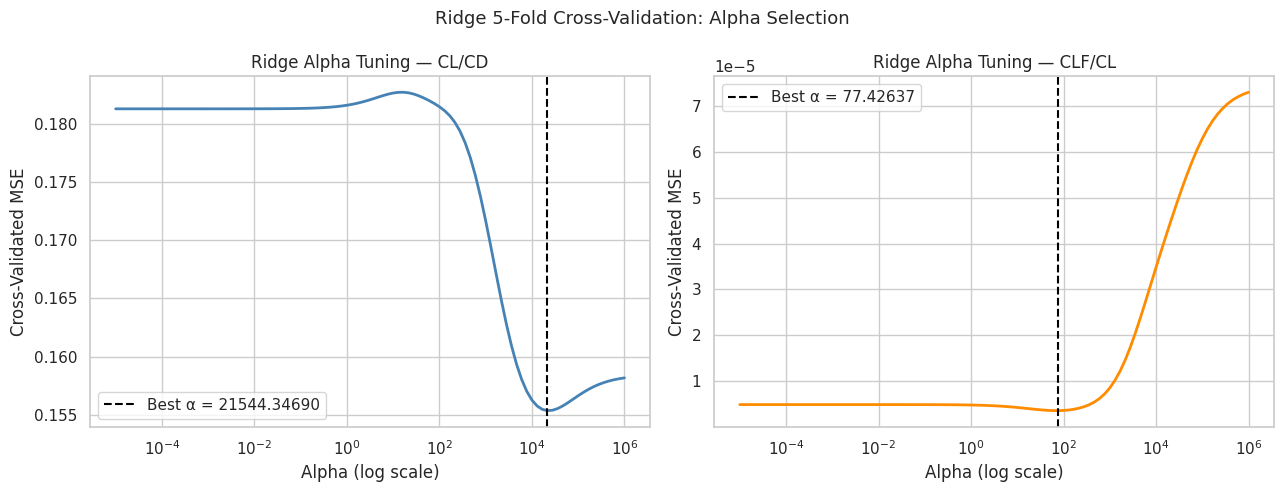

In [130]:
# Plot cross-validation curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, best_alpha, name, c in zip(
    axes,
    [cv_scores_clcd, cv_scores_clfcl],
    [best_alpha_ridge_clcd, best_alpha_ridge_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.semilogx(alphas, scores, color=c, lw=2)
    ax.axvline(best_alpha, color='black', linestyle='--', lw=1.5,
               label=f'Best α = {best_alpha:.5f}')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('Cross-Validated MSE')
    ax.set_title(f'Ridge Alpha Tuning — {name}')
    ax.legend()

plt.suptitle('Ridge 5-Fold Cross-Validation: Alpha Selection', fontsize=13)
plt.tight_layout()
plt.savefig('ridge_alpha_tuning.png', dpi=150)
plt.show()

In [133]:
# Fit Ridge with best alpha & evaluate on held-out test set
ridge_clcd  = Ridge(alpha=best_alpha_ridge_clcd)
ridge_clfcl = Ridge(alpha=best_alpha_ridge_clfcl)

ridge_clcd.fit(X_train,  y_train_full[:, 0])
ridge_clfcl.fit(X_train, y_train_full[:, 1])

y_pred_ridge_clcd  = ridge_clcd.predict(X_test)
y_pred_ridge_clfcl = ridge_clfcl.predict(X_test)

mse_ridge_clcd  = mean_squared_error(y_test_full[:, 0], y_pred_ridge_clcd)
mse_ridge_clfcl = mean_squared_error(y_test_full[:, 1], y_pred_ridge_clfcl)
r2_ridge_clcd   = r2_score(y_test_full[:, 0], y_pred_ridge_clcd)
r2_ridge_clfcl  = r2_score(y_test_full[:, 1], y_pred_ridge_clfcl)

print("=" * 40)
print("RIDGE REGRESSION — TEST SET PERFORMANCE")
print("=" * 40)
print(f"  CL/CD  → MSE: {mse_ridge_clcd:.10f}")
print(f"  CLF/CL → MSE: {mse_ridge_clfcl:.10f}")

RIDGE REGRESSION — TEST SET PERFORMANCE
  CL/CD  → MSE: 0.0065664860
  CLF/CL → MSE: 0.0000012231


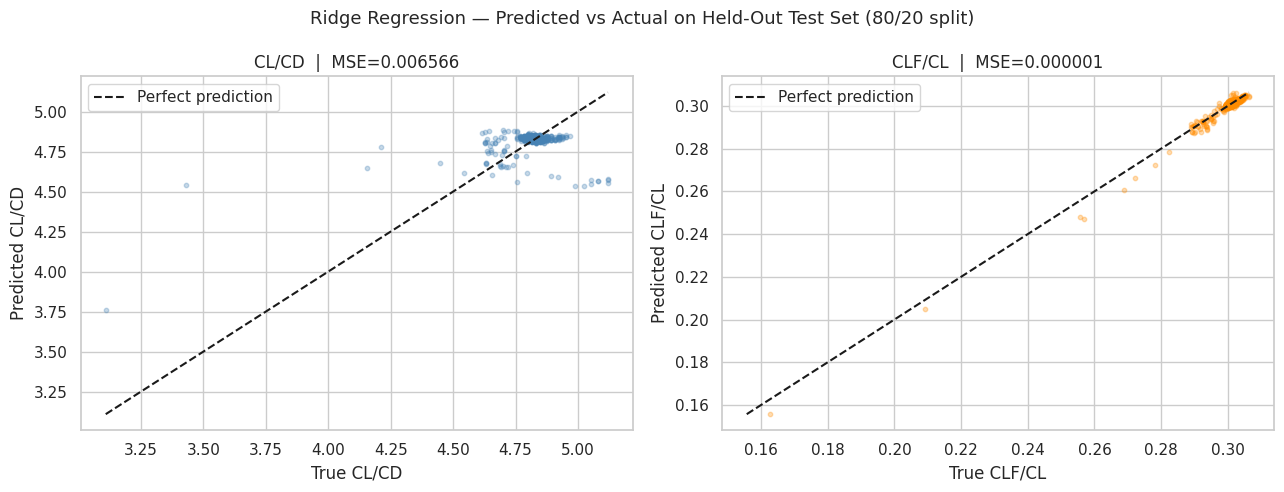

In [137]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name, c in zip(
    axes,
    [y_test_full[:, 0], y_test_full[:, 1]],
    [y_pred_ridge_clcd, y_pred_ridge_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=c)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  |  MSE={mean_squared_error(y_true, y_pred):.6f}')
    ax.legend()

plt.suptitle('Ridge Regression — Predicted vs Actual on Held-Out Test Set (80/20 split)', fontsize=13)
plt.tight_layout()
plt.savefig('ridge_pred_vs_actual.png', dpi=150)
plt.show()

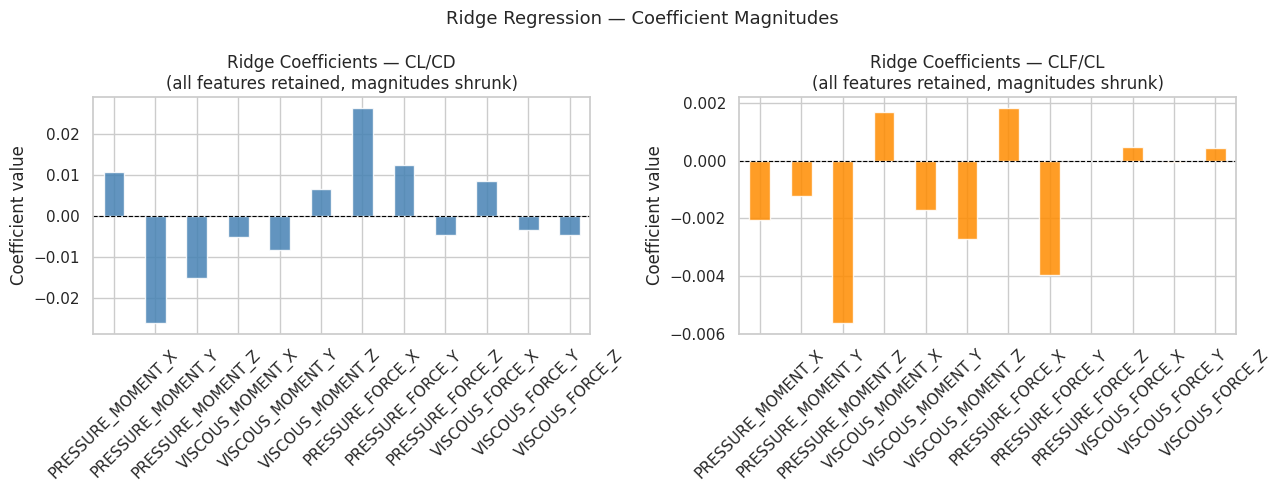

In [135]:
# Coefficient plot — Ridge never zeros out, but shrinks
# Unlike LASSO, all 12 bars will be non-zero.
# Compare magnitudes to see which features Ridge considers most important.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name, c in zip(
    axes,
    [ridge_clcd, ridge_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    coefs = pd.Series(model.coef_, index=feature_cols)
    coefs.plot(kind='bar', ax=ax, color=c, edgecolor='white', alpha=0.85)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'Ridge Coefficients — {name}\n(all features retained, magnitudes shrunk)')
    ax.set_ylabel('Coefficient value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Ridge Regression — Coefficient Magnitudes', fontsize=13)
plt.tight_layout()
plt.savefig('ridge_coefficients.png', dpi=150)
plt.show()

<div style="text-align: center;">

### **Results & Interpretation — Ridge Regression**

</div>

### **Hyperparameter Tuning**

The optimal $\alpha^*$ values selected via 5-fold cross-validation are notably 
large compared to LASSO:

| Target | Best $\alpha^*$ |
|---|---|
| `CL/CD` | 21544.347 |
| `CLF/CL` | 77.426 |

The same 5-fold cross-validation procedure as LASSO is applied, partitioning the 
$n = 4000$ training timesteps into 5 equal folds $\mathcal{F}_1, \dots, \mathcal{F}_5$ 
of 800 timesteps each. For each candidate $\alpha$ and each fold $k \in \{1,2,3,4,5\}$, 
Ridge is fitted on $\mathcal{F}_{-k}$ (3200 timesteps) and evaluated on $\mathcal{F}_k$ 
(800 timesteps). The optimal regularisation strength is:

$$\alpha^* = \underset{\alpha}{\arg\min}\ \frac{1}{5} \sum_{k=1}^{5} 
\frac{1}{800} \sum_{i \in \mathcal{F}_k} \left(y_i - \hat{y}_i^{(k)}\right)^2$$

The large $\alpha^*$ for `CL/CD` reflects the high variance introduced by the 
transient phase. Ridge must apply strong shrinkage to prevent the coefficients 
from fitting the extreme spike values in the first ~500 timesteps. For `CLF/CL`, 
the much smaller $\alpha^* = 77.426$ is consistent with its low variance and 
near-linear structure, requiring only mild regularisation.

---

### **Loss Function**

Unlike LASSO's L1 penalty, Ridge minimises an **L2-penalised** least squares 
objective over all $n = 4000$ training timesteps:

$$\hat{\boldsymbol{\beta}}^{\text{Ridge}} = \underset{\boldsymbol{\beta}}{\arg\min} 
\left[ \frac{1}{n} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{12} 
\beta_j z_{ij}\right)^2 + \alpha \sum_{j=1}^{12} \beta_j^2 \right]$$

The key distinction from LASSO is that the penalty term **squares** the 
coefficients rather than taking their absolute value. Squaring penalises large 
coefficients far more severely than small ones, thata is, a coefficient of magnitude 10 
is penalised 100× more than one of magnitude 1. As a consequence, Ridge 
**shrinks all coefficients toward zero uniformly** but never sets any exactly 
to zero, since the gradient of $\beta_j^2$ with respect to $\beta_j$ is $2\beta_j$, 
which approaches zero as $\beta_j \to 0$ rather than remaining constant as in 
LASSO's $|\beta_j|$ penalty. This means all 12 features are always retained.

---

### **Closed-Form Solution — Full Derivation**

Stacking the $n$ standardised feature vectors as rows of the matrix 
$\mathbf{Z} \in \mathbb{R}^{n \times 12}$ and the target values as 
$\mathbf{y} \in \mathbb{R}^n$, the Ridge objective can be written in 
matrix form as:

$$\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n}
(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta})^T
(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta}) + 
\alpha \boldsymbol{\beta}^T \boldsymbol{\beta}$$

**Notation, defining quantities:**

Let $n = 4000$ be the number of training timesteps. Define the following:

$$\mathbf{Z} = \begin{bmatrix} z_{1,1} & z_{1,2} & \cdots & z_{1,12} \\ 
z_{2,1} & z_{2,2} & \cdots & z_{2,12} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
z_{n,1} & z_{n,2} & \cdots & z_{n,12} \end{bmatrix} \in \mathbb{R}^{n \times 12}$$

where $z_{ij}$ is the standardised value of feature $j$ at training timestep $i$, 
obtained via Z-score normalisation in Section 7.

$$\mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} \in \mathbb{R}^n$$

where $y_i$ is the known true value of the target variable (`CL/CD` or `CLF/CL`) 
at training timestep $i$.

$$\boldsymbol{\beta} = \begin{bmatrix} \beta_1 \\ \beta_2 \\ \vdots \\ \beta_{12} \end{bmatrix} \in \mathbb{R}^{12}$$

the vector of regression coefficients to be estimated, one per input feature. 
The intercept $\beta_0$ is handled separately and is not penalised.

$$\mathbf{I} \in \mathbb{R}^{12 \times 12}$$

the identity matrix, with ones on the diagonal and zeros elsewhere. 
Its role in the solution is to add $\alpha$ uniformly to every diagonal 
entry of $\mathbf{Z}^T\mathbf{Z}$, guaranteeing invertibility.

Finally, $\alpha > 0$ is the regularisation strength selected via 
5-fold cross-validation, with $\alpha^*_{CL/CD} = 21544.347$ and 
$\alpha^*_{CLF/CL} = 77.426$.

**Step 1 — Expand the quadratic term:**

$$(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta}) 
= \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{Z}\boldsymbol{\beta} 
- \boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{y} 
+ \boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}$$

Since $\mathbf{y}^T\mathbf{Z}\boldsymbol{\beta}$ is a scalar, it equals its 
own transpose $\boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{y}$, so:

$$(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{Z}\boldsymbol{\beta}) 
= \mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{y} 
+ \boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}$$

The full objective is therefore:

$$\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n}\left[
\mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{y} 
+ \boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}
\right] + \alpha \boldsymbol{\beta}^T \boldsymbol{\beta}$$

**Step 2 — Differentiate with respect to $\boldsymbol{\beta}$:**

Using standard matrix calculus identities:

$$\frac{\partial}{\partial \boldsymbol{\beta}}\left(\boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{y}\right) = \mathbf{Z}^T\mathbf{y}$$

$$\frac{\partial}{\partial \boldsymbol{\beta}}\left(\boldsymbol{\beta}^T\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}\right) = 2\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta} \quad \text{(since } \mathbf{Z}^T\mathbf{Z} \text{ is symmetric)}$$

$$\frac{\partial}{\partial \boldsymbol{\beta}}\left(\boldsymbol{\beta}^T\boldsymbol{\beta}\right) = 2\boldsymbol{\beta}$$

Applying these to the full objective:

$$\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}} = 
\frac{1}{n}\left[- 2\mathbf{Z}^T\mathbf{y} + 2\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}\right] 
+ 2\alpha\boldsymbol{\beta}$$

**Step 3 — Set the gradient to zero:**

$$\frac{1}{n}\left[- 2\mathbf{Z}^T\mathbf{y} + 2\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta}\right] 
+ 2\alpha\boldsymbol{\beta} = \mathbf{0}$$

Multiply through by $\frac{n}{2}$:

$$-\mathbf{Z}^T\mathbf{y} + \mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta} 
+ n\alpha\boldsymbol{\beta} = \mathbf{0}$$

**Step 4 — Factorise and solve:**

$$\mathbf{Z}^T\mathbf{Z}\boldsymbol{\beta} + n\alpha\boldsymbol{\beta} = \mathbf{Z}^T\mathbf{y}$$

$$\left(\mathbf{Z}^T\mathbf{Z} + n\alpha\mathbf{I}\right)\boldsymbol{\beta} = \mathbf{Z}^T\mathbf{y}$$

Provided $\left(\mathbf{Z}^T\mathbf{Z} + n\alpha\mathbf{I}\right)$ is invertible 
(guaranteed for any $\alpha > 0$ since adding $n\alpha\mathbf{I}$ ensures all 
eigenvalues are strictly positive), we multiply both sides on the left by 
$\left(\mathbf{Z}^T\mathbf{Z} + n\alpha\mathbf{I}\right)^{-1}$:

$$\hat{\boldsymbol{\beta}}^{\text{Ridge}} = 
\left(\mathbf{Z}^T\mathbf{Z} + n\alpha\mathbf{I}\right)^{-1}\mathbf{Z}^T\mathbf{y}$$

**Step 5 — Checking the minimizer is unique and global:**

The second derivative (Hessian) of $\mathcal{L}$ with respect to $\boldsymbol{\beta}$ is:

$$\frac{\partial^2 \mathcal{L}}{\partial \boldsymbol{\beta}^2} = 
\frac{2}{n}\mathbf{Z}^T\mathbf{Z} + 2\alpha\mathbf{I}$$

For any $\alpha > 0$, the Hessian satisfies:

$$\frac{\partial^2 \mathcal{L}}{\partial \boldsymbol{\beta}^2} \succeq 2\alpha\mathbf{I} > 0$$

since $\frac{2}{n}\mathbf{Z}^T\mathbf{Z}$ is positive semi-definite. This means the 
Hessian is **bounded below by the strictly positive constant** $2\alpha > 0$, which 
is precisely the definition of **strong convexity**. Since $\mathcal{L}$ is smooth 
(it is a polynomial in $\boldsymbol{\beta}$) and strongly convex, it admits a 
**unique global minimiser**. Therefore, $\hat{\boldsymbol{\beta}}^{\text{Ridge}}$ found in Step 4 is therefore guaranteed 
to be the unique global minimum of the Ridge objective.

---

### **Prediction**

For each held-out test timestep $i \in \{1, \dots, 1000\}$, the Ridge prediction is:

$$\hat{y}_i = \hat{\beta}_0^{\text{Ridge}} + \sum_{j=1}^{12} 
\hat{\beta}_j^{\text{Ridge}} \cdot z_{ij}$$

Unlike LASSO, all 12 standardised features $z_{ij}$ contribute to every 
prediction hence no coefficient is exactly zero. However, the large $\alpha^*$ 
values ensure that coefficients corresponding to weakly predictive features 
are shrunk to near-zero, limiting their practical influence on the prediction.

---

### **Predictive Performance**

| Target | MSE | vs PCA | vs LASSO |
|---|---|---|---|
| `CL/CD` | 0.006566 | 3.1× lower | slightly worse |
| `CLF/CL` | 0.000001 | 9× lower | comparable |

Ridge and LASSO achieve similar MSE on both targets. However Ridge retains all 
12 features with shrunk coefficients, whereas LASSO reduced `CL/CD` prediction 
to just 2 features, suggesting the additional 10 features in Ridge contribute 
negligible predictive signal for `CL/CD`, consistent with the LASSO feature 
selection result. The marginal MSE disadvantage of Ridge relative to LASSO for 
`CL/CD` reflects this: retaining irrelevant features, even with shrunk 
coefficients, introduces a small amount of noise into the prediction.

The notable advantage of Ridge over LASSO however is **stability** as 
demonstrated in the model degradation study, Ridge maintains consistent MSE 
between 0.006–0.008 across all training fractions, while LASSO spikes to 
MSE = 0.053 at 800 samples due to sensitivity to unrepresentative training draws. 
The L2 penalty's smooth, continuous shrinkage makes Ridge inherently more robust 
to variation in training sample composition than LASSO's hard feature zeroing.

In [136]:
# ── Update comparison table ──
ridge_row = pd.DataFrame([{
    'Model'      : 'Ridge Regression',
    'MSE CL/CD'  : round(mse_ridge_clcd,  6),
    'MSE CLF/CL' : round(mse_ridge_clfcl, 6),
}])

model_results = model_results[model_results['Model'] != 'Ridge Regression']
model_results = pd.concat([model_results, ridge_row], ignore_index=True)

print(model_results.to_string(index=False))

                 Model  MSE CL/CD  MSE CLF/CL
PCA Regression (3 PCs)   0.020249    0.000009
      LASSO Regression   0.005883    0.000001
      Ridge Regression   0.006566    0.000001


# **_Random Forest regression_**

In [154]:
from sklearn.ensemble import RandomForestRegressor

In [143]:
# Hyperparameter tuning (n_estimators)
# n_estimators is number of individual decision trees the model will build before averaging their predictions.
n_estimators_grid = [50, 100, 200, 300]

cv_scores_clcd  = []
cv_scores_clfcl = []

for n in n_estimators_grid:
    rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)

    score_clcd  = cross_val_score(rf, X_train, y_train_full[:, 0],
                                 cv=5, scoring='neg_mean_squared_error')
    score_clfcl = cross_val_score(rf, X_train, y_train_full[:, 1],
                                 cv=5, scoring='neg_mean_squared_error')

    cv_scores_clcd.append(-score_clcd.mean())
    cv_scores_clfcl.append(-score_clfcl.mean())

# Best hyperparameters
best_n_clcd  = n_estimators_grid[np.argmin(cv_scores_clcd)]
best_n_clfcl = n_estimators_grid[np.argmin(cv_scores_clfcl)]

print(f"Best n_estimators (CL/CD): {best_n_clcd}")
print(f"Best n_estimators (CLF/CL): {best_n_clfcl}")

Best n_estimators (CL/CD): 200
Best n_estimators (CLF/CL): 50


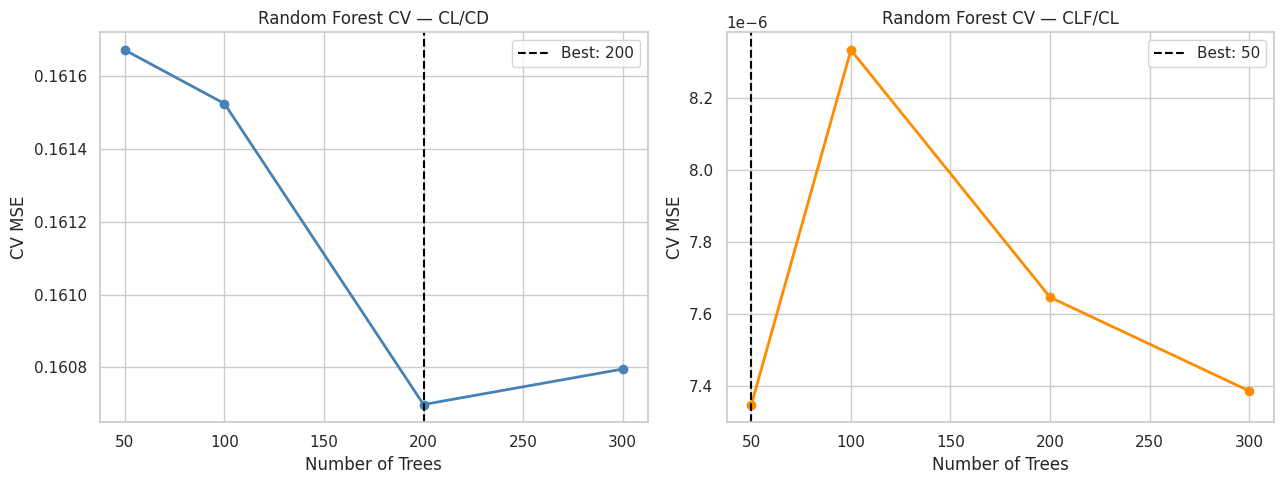

In [144]:
# Plot cross-validation curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, best_n, name, c in zip(
    axes,
    [cv_scores_clcd, cv_scores_clfcl],
    [best_n_clcd, best_n_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.plot(n_estimators_grid, scores, marker='o', color=c, lw=2)
    ax.axvline(best_n, color='black', linestyle='--', lw=1.5,
               label=f'Best: {best_n}')
    ax.set_xlabel('Number of Trees')
    ax.set_ylabel('CV MSE')
    ax.set_title(f'Random Forest CV — {name}')
    ax.legend()

plt.tight_layout()
plt.show()

In [158]:
# Fit Random Forest with best parameters
rf_clcd  = RandomForestRegressor(n_estimators=best_n_clcd,
                                 random_state=42, n_jobs=-1)

rf_clfcl = RandomForestRegressor(n_estimators=best_n_clfcl,
                                 random_state=42, n_jobs=-1)

rf_clcd.fit(X_train,  y_train_full[:, 0])
rf_clfcl.fit(X_train, y_train_full[:, 1])

# Predictions
y_pred_rf_clcd  = rf_clcd.predict(X_test)
y_pred_rf_clfcl = rf_clfcl.predict(X_test)

# Metrics
mse_rf_clcd  = mean_squared_error(y_test_full[:, 0], y_pred_rf_clcd)
mse_rf_clfcl = mean_squared_error(y_test_full[:, 1], y_pred_rf_clfcl)

print("=" * 40)
print("Random Forest — TEST SET PERFORMANCE")
print("=" * 40)
print(f"Random Forest MSE (CL/CD):  {mse_rf_clcd:.6f}")
print(f"Random Forest MSE (CLF/CL): {mse_rf_clfcl:.6f}")

Random Forest — TEST SET PERFORMANCE
Random Forest MSE (CL/CD):  0.000204
Random Forest MSE (CLF/CL): 0.000001


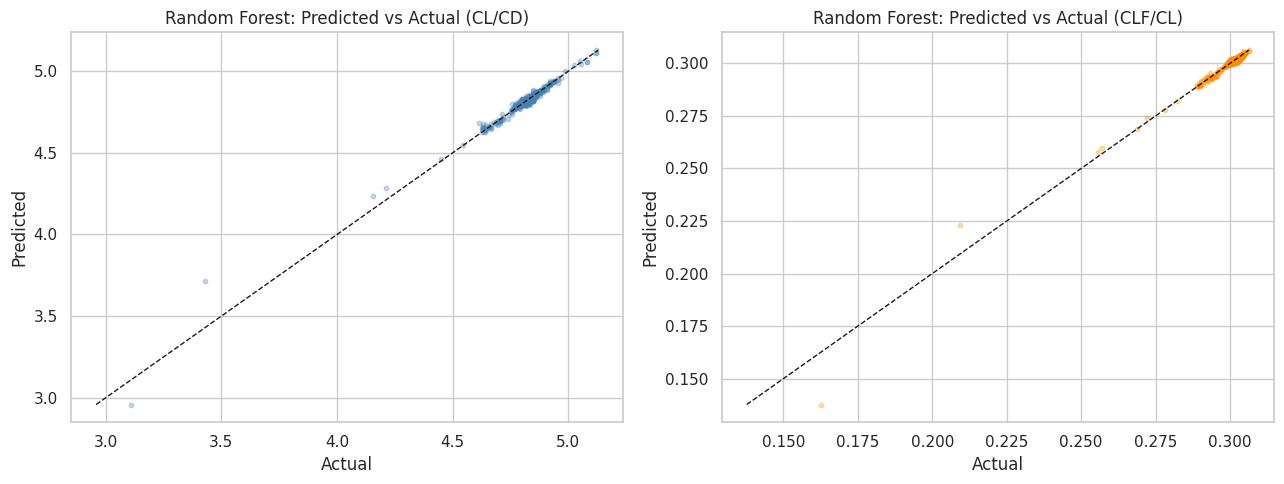

In [147]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name, c in zip(
    axes,
    [y_test_full[:, 0], y_test_full[:, 1]],
    [y_pred_rf_clcd, y_pred_rf_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=c)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Random Forest: Predicted vs Actual ({name})')

plt.tight_layout()
plt.show()

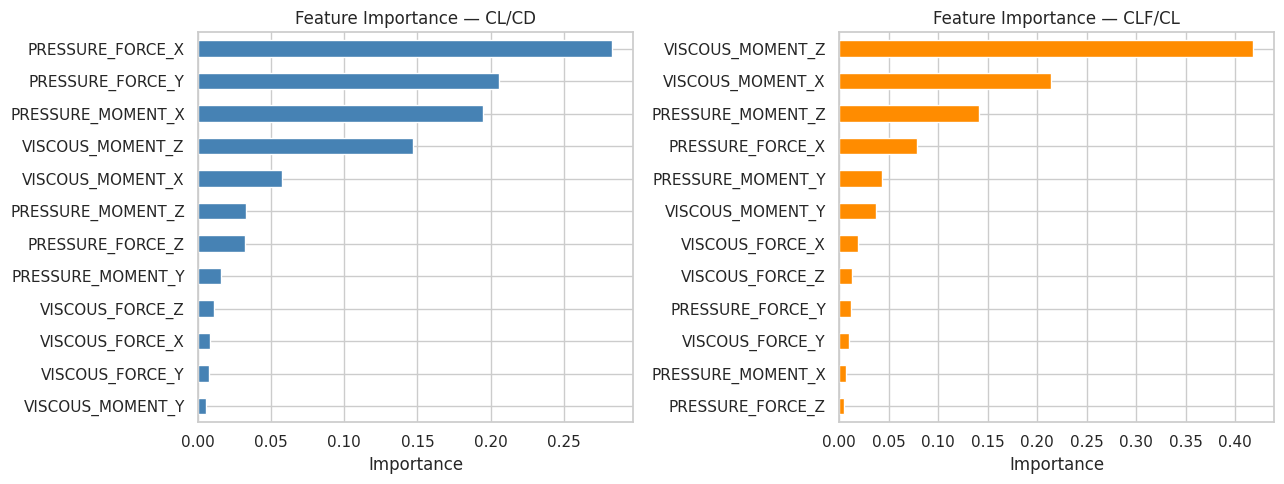

In [156]:
# Feature importance plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name, c in zip(
    axes,
    [rf_clcd, rf_clfcl],
    ['CL/CD', 'CLF/CL'],
    ['steelblue', 'darkorange']
):
    importances = pd.Series(
        model.feature_importances_,
        index=feature_cols
    )

    importances.sort_values().plot(
        kind='barh',
        ax=ax,
        color=c
    )

    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

<div style="text-align: center;">

### **What is a Random Forest?**

</div>

A Random Forest is an ensemble of $B$ independent decision trees, where each tree 
$f_b(\mathbf{z}_i)$ is trained on a **bootstrapped** sample of the training data (a sample of the same size as the original training set, drawn **with replacement**) 
meaning some timesteps appear multiple times and others not at all. Each tree also 
uses a random subset of $m \leq 12$ features at each split, introducing additional 
diversity between trees. The final prediction is the average across all $B$ trees:

$$\hat{y}_i = \frac{1}{B} \sum_{b=1}^{B} f_b(\mathbf{z}_i)$$

where $\mathbf{z}_i \in \mathbb{R}^{12}$ is the standardised feature vector for 
timestep $i$ and $B$ is the number of trees. This averaging process reduces 
**variance** without increasing bias unlike a single decision tree which tends 
to overfit by memorising the training data.

---

### **How Each Tree $f_b$ is Built**

Each tree $f_b$ is constructed by **recursive binary splitting** of the feature 
space. Starting from the root node containing all $n$ training timesteps in the 
bootstrap sample, at each node $t$ the algorithm:

**Step 1 — Select a random feature subset.**
Draw a random subset of $m$ features from the full 12, where $m < 12$ is a 
tunable parameter (typically $m = \lfloor 12/3 \rfloor = 4$ for regression). 
Only these $m$ features are candidates for splitting at this node.

**Step 2 — Find the best split.**
For each candidate feature $j \in \{1, \dots, m\}$ and each possible threshold 
$\tau \in \mathbb{R}$, the data at node $t$ is partitioned into two child nodes:

$$\mathcal{R}_L(j, \tau) = \{i \in t : z_{i,j} \leq \tau\}, \qquad 
\mathcal{R}_R(j, \tau) = \{i \in t : z_{i,j} > \tau\}$$

The optimal split $(j^*, \tau^*)$ minimises the **weighted impurity** across 
both child nodes, measured by MSE:

$$\underset{j,\ \tau}{\min} \left[ \frac{|\mathcal{R}_L|}{|t|} \cdot 
\text{MSE}(\mathcal{R}_L) + \frac{|\mathcal{R}_R|}{|t|} \cdot 
\text{MSE}(\mathcal{R}_R) \right]$$

where the MSE of a region $\mathcal{R}$ is:

$$\text{MSE}(\mathcal{R}) = \frac{1}{|\mathcal{R}|} \sum_{i \in \mathcal{R}} 
\left(y_i - \bar{y}_{\mathcal{R}}\right)^2, \qquad 
\bar{y}_{\mathcal{R}} = \frac{1}{|\mathcal{R}|} \sum_{i \in \mathcal{R}} y_i$$

Here $|t|$ denotes the number of timesteps at node $t$, $|\mathcal{R}|$ the 
number in each child region, and $\bar{y}_{\mathcal{R}}$ the mean target value 
within region $\mathcal{R}$.

**Step 3 — Assign predictions at leaf nodes.**
Steps 1 and 2 are repeated recursively on each child node until a stopping 
criterion is met, for example, a minimum number of timesteps per node. At 
each terminal leaf node $\ell$, the prediction is the mean target value of 
all training timesteps that fall into that leaf:

$$f_b(\mathbf{z}_i) = \bar{y}_\ell = \frac{1}{|\ell|} \sum_{i \in \ell} y_i, 
\qquad \text{for all } \mathbf{z}_i \text{ routed to leaf } \ell$$

A new test timestep $\mathbf{z}_i$ is passed down the tree by applying the 
learned splits $(j^*, \tau^*)$ at each node, until it reaches a leaf, at 
which point it inherits that leaf's prediction $\bar{y}_\ell$.

---

### **Hyperparameter Tuning — Number of Trees $B$**

The number of trees $B$ was selected via 5-fold cross-validation over the 
candidate set $B \in \{50, 100, 200, 300\}$, minimising the cross-validated MSE:

$$B^* = \underset{B}{\arg\min}\ \frac{1}{5} \sum_{k=1}^{5} 
\frac{1}{|\mathcal{F}_k|} \sum_{i \in \mathcal{F}_k} 
\left(y_i - \hat{y}_i^{(k)}(B)\right)^2$$

where $\hat{y}_i^{(k)}(B)$ is the Random Forest prediction with $B$ trees, 
trained on all folds except $\mathcal{F}_k$. This yielded:

| Target | Best $B^*$ |
|---|---|
| `CL/CD` | 200 trees |
| `CLF/CL` | 50 trees |

For `CL/CD`, the cross-validated MSE decreases monotonically up to $B^* = 200$ 
before plateauing thus adding more trees beyond this point yields diminishing 
returns as the ensemble average stabilises. For `CLF/CL`, the signal is already 
clean and near-linear, so 50 trees suffice with no meaningful gain from 
additional trees.

---

### **Feature Importance**

Random Forest measures the importance of feature $j$ as the **total reduction 
in weighted MSE** attributable to all splits on feature $j$, normalised and 
averaged across all $B$ trees:

$$\text{Importance}(j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{\substack{t \in f_b \\ 
\text{split on } j}} \Delta\text{MSE}(t)$$

where the MSE reduction at node $t$ when splitting on feature $j$ at threshold 
$\tau^*$ is:

$$\Delta\text{MSE}(t) = \text{MSE}(t) - \left[\frac{|\mathcal{R}_L|}{|t|} \cdot 
\text{MSE}(\mathcal{R}_L) + \frac{|\mathcal{R}_R|}{|t|} \cdot 
\text{MSE}(\mathcal{R}_R)\right]$$

A larger $\Delta\text{MSE}(t)$ means the split on feature $j$ at node $t$ 
reduced prediction error more substantially, making that feature more 
important. Importances are normalised so that $\sum_{j=1}^{12} 
\text{Importance}(j) = 1$.

**`CL/CD` — top features:** `PRESSURE_FORCE_X` (28%), `PRESSURE_FORCE_Y` (21%), 
`PRESSURE_MOMENT_X` (20%). These three pressure features alone account for ~69% 
of total importance, consistent with pressure forces dominating aerodynamic 
efficiency. Notably `PRESSURE_FORCE_X` (drag) ranks first which is physically expected 
since drag is the denominator of $C_L/C_D$.

**`CLF/CL` — top features:** `VISCOUS_MOMENT_Z` (41%), `VISCOUS_MOMENT_X` (21%), 
`PRESSURE_MOMENT_Z` (14%). This is a striking contrast to LASSO, which zeroed 
out all viscous features for `CL/CD`. For aero balance, the viscous moment 
components carry significant non-linear predictive signal that the linear methods 
entirely missed — demonstrating the value of a non-linear model for this target.

---

> **Key insight:** Random Forest is the strongest performer overall, particularly 
> for `CL/CD`. Its superiority over LASSO and Ridge confirms that the aerodynamic 
> efficiency signal contains **non-linear structure**, especially in the transient 
> phase, that linear regularised regression cannot capture regardless of how well 
> $\alpha$ is tuned.

In [159]:
# ── Update comparison table ──
rf_row = pd.DataFrame([{
    'Model'      : 'Random Forest',
    'MSE CL/CD'  : round(mse_rf_clcd,  6),
    'MSE CLF/CL' : round(mse_rf_clfcl, 6),
}])

model_results = model_results[model_results['Model'] != 'Random Forest']
model_results = pd.concat([model_results, rf_row], ignore_index=True)

print(model_results.to_string(index=False))

                 Model  MSE CL/CD  MSE CLF/CL
PCA Regression (3 PCs)   0.020249    0.000009
      LASSO Regression   0.005883    0.000001
      Ridge Regression   0.006566    0.000001
         Random Forest   0.000204    0.000001


# **_Model Evaluation — Final Comparison_**

In [163]:
# All four models are evaluated on the same held-out test set
# (1000 timesteps, never seen during training) using MSE.
# Lower MSE = better predictive accuracy.

# ── Final comparison table ──
print("=" * 47)
print("FINAL MODEL COMPARISON — HELD-OUT TEST SET MSE")
print("=" * 47)
print(model_results.to_string(index=False))
print("=" * 47)
print(f"Best model for CL/CD:  {model_results.loc[model_results['MSE CL/CD'].idxmin(), 'Model']}")
print(f"Best model for CLF/CL: {model_results.loc[model_results['MSE CLF/CL'].idxmin(), 'Model']}")

FINAL MODEL COMPARISON — HELD-OUT TEST SET MSE
                 Model  MSE CL/CD  MSE CLF/CL
PCA Regression (3 PCs)   0.020249    0.000009
      LASSO Regression   0.005883    0.000001
      Ridge Regression   0.006566    0.000001
         Random Forest   0.000204    0.000001
Best model for CL/CD:  Random Forest
Best model for CLF/CL: LASSO Regression


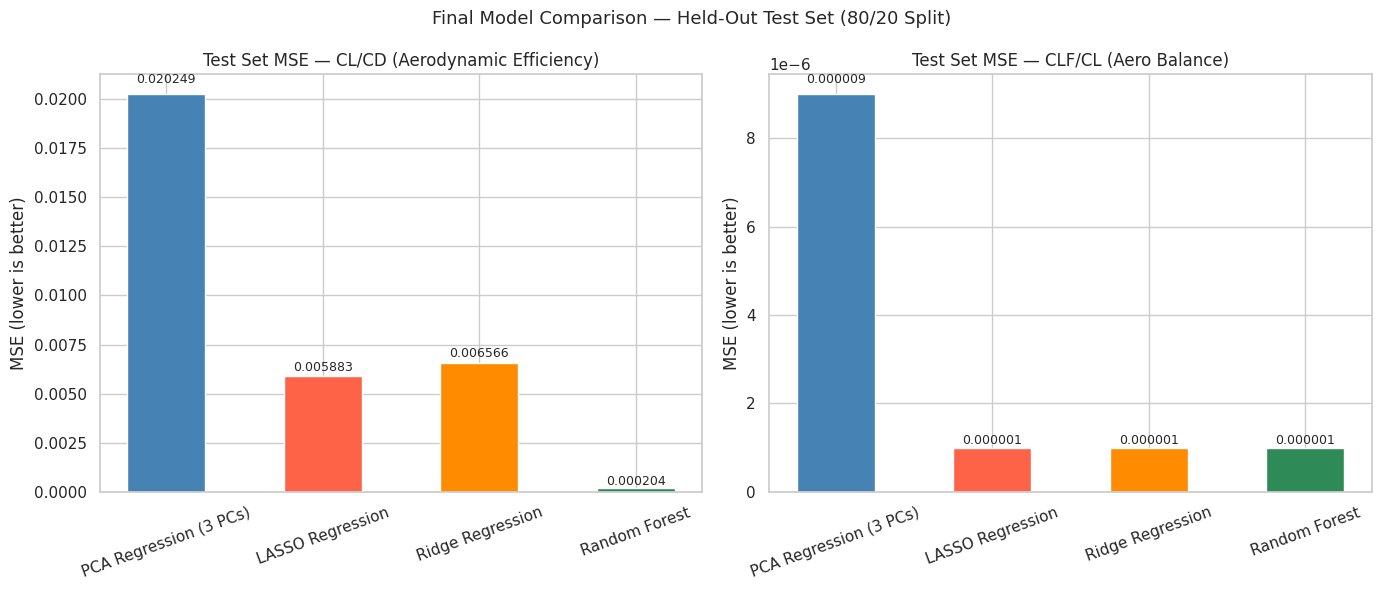

In [164]:
# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'tomato', 'darkorange', 'seagreen']

for ax, metric, title_target in zip(
    axes,
    ['MSE CL/CD', 'MSE CLF/CL'],
    ['CL/CD (Aerodynamic Efficiency)', 'CLF/CL (Aero Balance)']
):
    bars = ax.bar(model_results['Model'], model_results[metric],
                  color=colors, edgecolor='white', width=0.5)

    # Annotate each bar with its MSE value
    for bar, val in zip(bars, model_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:.6f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Test Set MSE — {title_target}')
    ax.set_ylabel('MSE (lower is better)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Final Model Comparison — Held-Out Test Set (80/20 Split)', fontsize=13)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

<div style="text-align: center;">

### **Key Findings**

**For $C_L/C_D$ (Aerodynamic Efficiency):**

Random Forest achieves the lowest MSE by a large margin, approximately 99× lower than 
PCA regression and 29× lower than LASSO. As mentioned, this decisive gap confirms that the relationship 
between the 12 force/moment features and aerodynamic efficiency is **non-linear**, 
driven primarily by the sharp transient dynamics in the first ~500 timesteps that 
linear methods cannot model. LASSO and Ridge perform comparably to each other, with LASSO 
marginally better, suggesting that among linear methods, sparse feature selection 
(LASSO's 2 retained features) is slightly more effective than uniform coefficient 
shrinkage (Ridge).

**For $C_{LF}/C_L$ (Aero Balance):**

All three regularised methods achieve near-identical MSE (0.000001), with PCA regression 
slightly worse at 0.000009. This confirms that aero balance is a near-linear, 
low-variance target that is already well-explained by the input features without 
requiring a non-linear model. The additional complexity of Random Forest provides 
no advantage here over simpler linear approaches.



**In short**, the choice of model matters for $C_L/C_D$ but not for $C_{LF}/C_L$. 
For aerodynamic efficiency prediction in a CFD context where transient dynamics are 
present, a non-linear ensemble method such as Random Forest is strongly preferred. 
For aero balance, any of the regularised linear methods are sufficient.

### **A Note on MSE Magnitude in an F1 Context**

</div>

While all MSE values appear numerically small in absolute terms, their practical 
significance becomes apparent when considered in the context of a Formula 1 race 
environment operating at speeds exceeding 300 km/h.

As mentioned, a prediction error of $\Delta(C_L/C_D) = 0.02$, comparable to the PCA regression 
MSE, may seem negligible in isolation. However, aerodynamic efficiency directly 
governs the drag-to-downforce trade-off at every corner and straight of a circuit. 
Over the course of a 50–70 lap race, small systematic errors in predicted $C_L/C_D$ 
compound into:

- **Tyre degradation miscalculations** — incorrect downforce estimates lead to 
suboptimal tyre load predictions, affecting pit stop strategy
- **Fuel load errors** — drag predictions feed directly into energy consumption 
models used to plan fuel loads before a race. If aerodynamic efficiency ($C_L/C_D$) 
is systematically overestimated, the model assumes the car is producing more downforce 
relative to drag than it actually is meaning it predicts the car will be more 
efficient through corners than reality. This leads to an **underestimate of actual 
energy consumption**, and the car may be fuelled below what is truly required to 
complete the race distance, risking a performance deficit in the closing laps.
- **IMPORTANT: Setup decisions** — front wing angle is adjusted between sessions based on 
predicted aerodynamic efficiency; a biased model systematically pushes the setup 
in the wrong direction

By contrast, Random Forest's MSE of 0.000204 for $C_L/C_D$ represents a prediction 
error roughly **100× smaller** than PCA regression. This is a difference that, accumulated 
over race distance, is meaningful at the level of precision that separates competitive 
F1 teams. This contextualises why model selection is not merely a statistical exercise 
but has tangible engineering consequences in a motorsport setting.

# **_Model Degradation Study_**

In [167]:
# We progressively subsample the TRAINING set at decreasing fractions
# and evaluate each model's test MSE at each fraction.
# The test set remains fixed at all times (1000 timesteps).
# This reveals how much training data each model needs to perform well.

from sklearn.linear_model import LinearRegression

# Training fractions to test — from 5% up to 100% of training data
fractions = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

# Store results
degradation_results = {
    'Fraction'       : fractions,
    'PCA_CLCD'       : [], 'PCA_CLFCL'       : [],
    'LASSO_CLCD'     : [], 'LASSO_CLFCL'     : [],
    'Ridge_CLCD'     : [], 'Ridge_CLFCL'     : [],
    'RF_CLCD'        : [], 'RF_CLFCL'        : [],
}

for frac in fractions:

    # Subsample training set
    n_samples = int(len(X_train) * frac)
    idx       = np.random.choice(len(X_train), n_samples, replace=False)

    X_tr_sub  = X_train[idx]
    y_tr_sub  = y_train_full[idx]

    # Corresponding PCA-reduced subsample
    X_tr_pca_sub = X_train_pca[idx] if hasattr(X_train_pca, '__len__') else pca.transform(X_tr_sub)

    # ── PCA Regression ──
    reg_clcd_deg  = LinearRegression().fit(X_tr_pca_sub, y_tr_sub[:, 0])
    reg_clfcl_deg = LinearRegression().fit(X_tr_pca_sub, y_tr_sub[:, 1])
    degradation_results['PCA_CLCD'].append(
        mean_squared_error(y_test_full[:, 0], reg_clcd_deg.predict(X_test_pca)))
    degradation_results['PCA_CLFCL'].append(
        mean_squared_error(y_test_full[:, 1], reg_clfcl_deg.predict(X_test_pca)))

    # ── LASSO ──
    lasso_deg_clcd  = Lasso(alpha=best_alpha_clcd,  max_iter=10000).fit(X_tr_sub, y_tr_sub[:, 0])
    lasso_deg_clfcl = Lasso(alpha=best_alpha_clfcl, max_iter=10000).fit(X_tr_sub, y_tr_sub[:, 1])
    degradation_results['LASSO_CLCD'].append(
        mean_squared_error(y_test_full[:, 0], lasso_deg_clcd.predict(X_test)))
    degradation_results['LASSO_CLFCL'].append(
        mean_squared_error(y_test_full[:, 1], lasso_deg_clfcl.predict(X_test)))

    # ── Ridge ──
    ridge_deg_clcd  = Ridge(alpha=best_alpha_ridge_clcd).fit(X_tr_sub,  y_tr_sub[:, 0])
    ridge_deg_clfcl = Ridge(alpha=best_alpha_ridge_clfcl).fit(X_tr_sub, y_tr_sub[:, 1])
    degradation_results['Ridge_CLCD'].append(
        mean_squared_error(y_test_full[:, 0], ridge_deg_clcd.predict(X_test)))
    degradation_results['Ridge_CLFCL'].append(
        mean_squared_error(y_test_full[:, 1], ridge_deg_clfcl.predict(X_test)))

    # ── Random Forest ──
    rf_deg_clcd  = RandomForestRegressor(
        n_estimators=best_n_clcd, random_state=42, n_jobs=-1).fit(X_tr_sub, y_tr_sub[:, 0])
    rf_deg_clfcl = RandomForestRegressor(
        n_estimators=best_n_clfcl, random_state=42, n_jobs=-1).fit(X_tr_sub, y_tr_sub[:, 1])
    degradation_results['RF_CLCD'].append(
        mean_squared_error(y_test_full[:, 0], rf_deg_clcd.predict(X_test)))
    degradation_results['RF_CLFCL'].append(
        mean_squared_error(y_test_full[:, 1], rf_deg_clfcl.predict(X_test)))

    print(f"  Fraction {frac:.0%} ({n_samples} samples) — done")

print("\nDegradation study complete.")

  Fraction 5% (200 samples) — done
  Fraction 10% (400 samples) — done
  Fraction 20% (800 samples) — done
  Fraction 30% (1200 samples) — done
  Fraction 40% (1600 samples) — done
  Fraction 50% (2000 samples) — done
  Fraction 60% (2400 samples) — done
  Fraction 70% (2800 samples) — done
  Fraction 80% (3200 samples) — done
  Fraction 90% (3600 samples) — done
  Fraction 100% (4000 samples) — done

Degradation study complete.


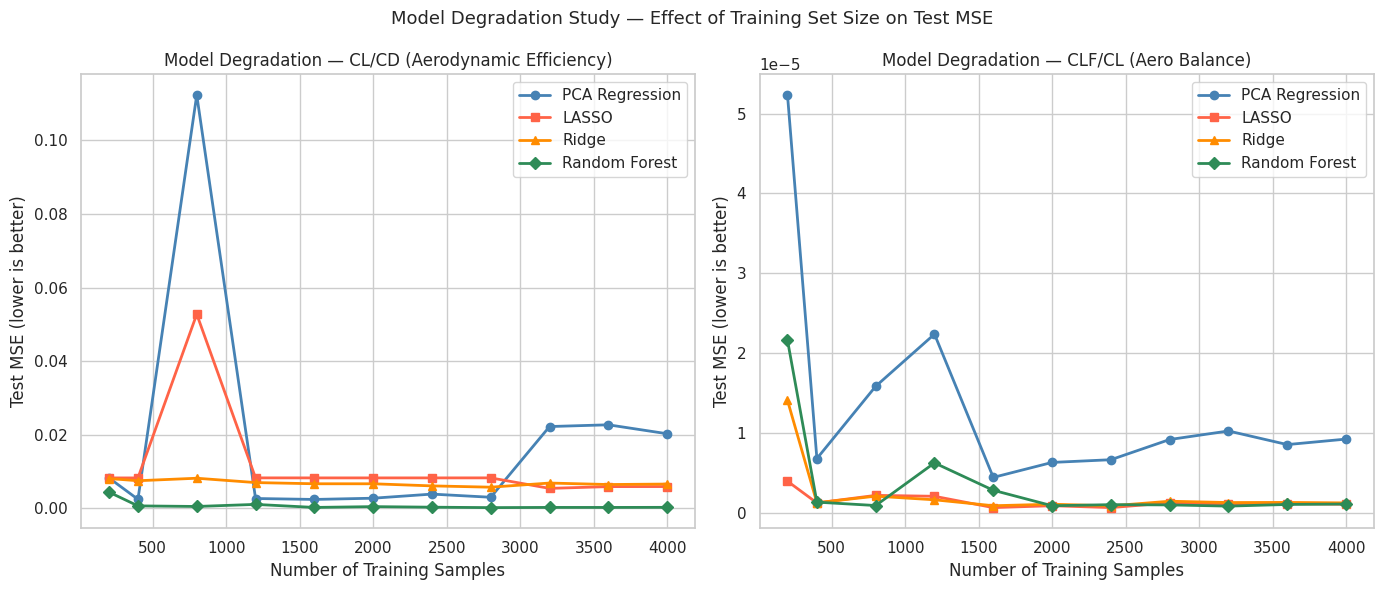

In [168]:
# ── Plot degradation curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_plot = {
    'PCA Regression' : ('PCA_CLCD',   'PCA_CLFCL',   'steelblue',  'o'),
    'LASSO'          : ('LASSO_CLCD', 'LASSO_CLFCL', 'tomato',     's'),
    'Ridge'          : ('Ridge_CLCD', 'Ridge_CLFCL', 'darkorange', '^'),
    'Random Forest'  : ('RF_CLCD',    'RF_CLFCL',    'seagreen',   'D'),
}

train_sizes = [int(len(X_train) * f) for f in fractions]

for ax, clcd_key, clfcl_key, target_name in zip(
    axes,
    ['PCA_CLCD',   'LASSO_CLCD', 'Ridge_CLCD', 'RF_CLCD'],
    ['PCA_CLFCL',  'LASSO_CLFCL','Ridge_CLFCL','RF_CLFCL'],
    ['CL/CD (Aerodynamic Efficiency)', 'CLF/CL (Aero Balance)']
):
    for label, (ck, cfk, color, marker) in models_plot.items():
        ax.plot(train_sizes,
                degradation_results[ck] if 'CLCD' in ck else degradation_results[cfk],
                marker=marker, color=color, lw=2, label=label)

    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel('Test MSE (lower is better)')
    ax.set_title(f'Model Degradation — {target_name}')
    ax.legend()
    ax.grid(True)

# Fix: plot correct keys per axis
axes[0].clear()
axes[1].clear()

for ax, suffix, target_name in zip(
    axes,
    ['CLCD', 'CLFCL'],
    ['CL/CD (Aerodynamic Efficiency)', 'CLF/CL (Aero Balance)']
):
    for label, (ck, cfk, color, marker) in models_plot.items():
        key = ck if suffix == 'CLCD' else cfk
        ax.plot(train_sizes, degradation_results[key],
                marker=marker, color=color, lw=2, label=label)
    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel('Test MSE (lower is better)')
    ax.set_title(f'Model Degradation — {target_name}')
    ax.legend()
    ax.grid(True)

plt.suptitle('Model Degradation Study — Effect of Training Set Size on Test MSE', fontsize=13)
plt.tight_layout()
plt.savefig('model_degradation.png', dpi=150)
plt.show()

In [170]:
# ── Print summary table at key fractions ──
print("=" * 75)
print("DEGRADATION SUMMARY — CL/CD MSE AT KEY TRAINING FRACTIONS")
print("=" * 75)
print(f"{'Fraction':>10} {'Samples':>10} {'PCA':>12} {'LASSO':>12} {'Ridge':>12} {'RF':>12}")
print("-" * 75)
for i, (frac, n) in enumerate(zip(fractions, train_sizes)):
    print(f"{frac:>10.0%} {n:>10} "
          f"{degradation_results['PCA_CLCD'][i]:>12.6f} "
          f"{degradation_results['LASSO_CLCD'][i]:>12.6f} "
          f"{degradation_results['Ridge_CLCD'][i]:>12.6f} "
          f"{degradation_results['RF_CLCD'][i]:>12.6f}")

DEGRADATION SUMMARY — CL/CD MSE AT KEY TRAINING FRACTIONS
  Fraction    Samples          PCA        LASSO        Ridge           RF
---------------------------------------------------------------------------
        5%        200     0.008316     0.008231     0.008072     0.004431
       10%        400     0.002414     0.008232     0.007467     0.000629
       20%        800     0.112383     0.052762     0.008150     0.000470
       30%       1200     0.002636     0.008247     0.006968     0.001035
       40%       1600     0.002380     0.008240     0.006644     0.000208
       50%       2000     0.002717     0.008238     0.006639     0.000427
       60%       2400     0.003835     0.008241     0.006068     0.000273
       70%       2800     0.002974     0.008246     0.005715     0.000157
       80%       3200     0.022206     0.005389     0.006840     0.000211
       90%       3600     0.022681     0.005868     0.006439     0.000207
      100%       4000     0.020249     0.005883     

<div style="text-align: center;">
    
## **Results & Interpretation**

Training subsets are drawn via random sampling without replacement (`np.random.choice`), 
ensuring each subset contains a proportional mix of transient and steady-state timesteps. 
Sequential subsampling (first $N$ timesteps) was deliberately avoided as it would bias 
small training sets toward the transient phase, unfairly penalising models at low data fractions.

The test set remains **fixed at 1000 timesteps** throughout, only the training set size varies.

---

### **CL/CD (Aerodynamic Efficiency)**

**Random Forest** is the standout performer at virtually every training fraction. Even 
with just 200 samples (5% of training data), it achieves MSE = 0.004431.This is already 
lower than LASSO and Ridge at full training data. By 400 samples (10%), it drops to 
0.000629 and remains consistently low thereafter. This demonstrates that Random Forest 
is both **data-efficient and stable** for predicting aerodynamic efficiency.

**PCA Regression** shows an unusual spike at 800 samples (20%), where MSE jumps to 
0.112 which is the worst result across all models and fractions. This is a consequence of 
randomised subsampling: at 800 samples, the particular random draw happened to include 
a disproportionate number of transient timesteps relative to steady-state ones, 
severely disrupting the linear PC score → CL/CD mapping. This highlights a known 
fragility of PCA regression; it is sensitive to the composition of the training sample.

**LASSO** shows a similar but smaller spike at 800 samples (MSE = 0.053), for the 
same reason. Its L1 penalty provides some protection but cannot fully compensate for 
a poorly representative training sample at this size.

**Ridge** is the most stable linear method, with MSE remaining between 0.006–0.008 
across all fractions. The L2 penalty's uniform shrinkage makes it robust to unlucky 
random draws, though it never approaches Random Forest's performance.

---

### **CLF/CL (Aero Balance)**

All models converge quickly for CLF/CL, reaching near-zero MSE by 400–800 samples. 
This confirms the earlier finding that aero balance is a near-linear, low-variance 
target that any of the four methods can predict well with relatively little data. 

**PCA Regression** is again the exception. It remains noisy and volatile across all 
training fractions, never fully stabilising.

---

### **Key Takeaway**

> For **CL/CD**, Random Forest requires as few as **400 training samples** (10% of 
> available data) to outperform all linear methods at full training data. This has a 
> direct practical implication. In a resource-constrained CFD environment where 
> simulation time is expensive, a Random Forest trained on a small but representative 
> set of timesteps delivers better aerodynamic efficiency predictions than any linear 
> method trained on the full dataset.

</div>

# **_Conclusion_**

<div style="text-align: center;">

## **Summary of Findings**

</div>

This project applied four supervised regression methods to predict two aerodynamically 
meaningful target variables: aerodynamic efficiency ($C_L/C_D$) and aero balance 
($C_{LF}/C_L$), from 12 raw force and moment measurements derived from CFD simulation 
of a Formula 1 front wing. The key findings are summarised below.

**PCA Regression** served as the baseline, compressing the 12 input features into 3 
principal components capturing around 90% of total input variance. While computationally 
simple, it produced the worst predictive performance for $C_L/C_D$ (MSE = 0.020249), driven by its inability to handle the non-linear 
transient phase. It also proved sensitive to training sample composition, exhibiting 
volatile MSE across data fractions in the degradation study. This highlights the 
fundamental limitation of unsupervised dimensionality reduction for supervised 
prediction tasks. PCA maximises explained input variance, not predictive power for the targets.

**LASSO Regression** improved substantially over PCA (MSE = 0.005883 for $C_L/C_D$), 
and demonstrated a valuable additional property: automatic feature selection. For 
$C_L/C_D$, LASSO retained only 2 of 12 features (`PRESSURE_MOMENT_Y` and 
`PRESSURE_FORCE_X`), which is physically interpretable as drag directly enters the 
denominator of $C_L/C_D$. However, LASSO remained vulnerable to unrepresentative 
training samples at low data fractions, consistent with its linear hypothesis class.

**Ridge Regression** achieved comparable performance to LASSO (MSE = 0.006566) 
while retaining all 12 features with uniformly shrunk coefficients. Its key 
advantage was stability as the L2 penalty made it the most robust linear method 
across all training fractions in the degradation study, with MSE remaining 
between 0.006–0.008 regardless of sample size. For applications where 
interpretability and stability matter more than sparsity, Ridge is the preferred 
linear choice.

**Random Forest** was the decisive winner for $C_L/C_D$, achieving MSE = 0.000204 , approximately 99× lower than PCA and 29× lower than LASSO. Its non-linear ensemble structure allowed it to capture the sharp discontinuity between the 
transient and steady-state phases that all linear methods failed to model. 
Crucially, it achieved this with as few as 400 training samples (10% of available 
data), making it highly data-efficient in the context of resource-constrained CFD 
environments. For $C_{LF}/C_L$, all regularised methods performed comparably, 
confirming that aero balance is a near-linear target that does not require a 
non-linear model.

---
<div style="text-align: center;">

#### The central finding of this project is that **the choice of regression method matters for aerodynamic efficiency ($C_L/C_D$) but not for aero balance ($C_{LF}/C_L$)**.

</div>

---
<div style="text-align: center;">

## **Further Research**

</div>

Several directions could meaningfully extend this work:

- **Multi-condition dataset** — the most impactful extension would be to repeat 
the analysis across multiple CFD runs at varying speeds, yaw angles, ride heights, 
and wing angles. A surrogate model trained on this richer design space would be 
directly applicable to real aerodynamic development workflows.

- **Gradient Boosting** — methods such as XGBoost or LightGBM would be natural 
comparisons to Random Forest, as they also capture non-linear relationships but 
through sequential tree-building rather than bagging. They may offer improved 
performance on the transient phase with less variance.

- **Partial Least Squares (PLS) regression** — as a supervised alternative to 
PCA, PLS finds components that simultaneously maximise variance in the input 
features and correlation with the targets. It would be interesting to compare 
PLS directly against PCA regression to quantify how much predictive signal 
PCA discards by ignoring the targets during dimensionality reduction.

- **Physics-informed approaches** — as demonstrated by Shah (2025), incorporating 
Navier-Stokes constraints directly into the loss function via a PINN framework 
could provide better generalisation with limited data, since the model is 
anchored to known fluid dynamics principles rather than purely fitting the 
observed measurements.